# Neurochirurgie sur les Transformers

## Introduction

Aujourd'hui, nous allons explorer les SAE (Auto-Encodeurs Parcimonieux). Cette technique a récemment fait parler d'elle grâce à un article d'Anthropic qui a révélé que Claude, leur modèle d'IA, avait identifié le concept de "Golden Bridge" grâce à cette méthode, et s'était même mis à prétendre qu'il était lui-même le fameux pont de San Francisco...

Notre objectif est de comprendre comment les SAE peuvent nous aider à décoder le fonctionnement interne des réseaux de neurones, en particulier des Transformers, qui sont à la base des LLMs comme ChatGPT, mais également de modèles de vision.

## Notre approche

1. **Entraînement d'un Transformer** : Nous allons d'abord entraîner un modèle Transformer sur le classique dataset MNIST (reconnaissance de chiffres manuscrits).

2. **Extraction des activations** : Une fois le modèle entraîné, nous allons extraire les activations du MLP (Multi-Layer Perceptron) lorsqu'on lui présente une image issue du MNIST.

3. **Entraînement d'un SAE** : Nous utiliserons ces activations comme données d'entrée pour entraîner un Auto-Encodeur Parcimonieux. Le SAE va apprendre de lui-même quels sont les concepts importants encodés dans cette couche du MLP.

4. **Intervention (neuro-chirurgie)** : Nous utiliserons cette séparation faite par le SAE pour intervenir sur les neurones par le biais du décodeur du SAE.

Cette approche nous permettra de "ouvrir la boîte noire" du Transformer et de comprendre quels types de caractéristiques ou de concepts il a appris à reconnaître dans les images de chiffres.

## Pourquoi est-ce important ?

L'interprétabilité des modèles d'apprentissage profond est un enjeu majeur en IA. Les SAE offrent une méthode prometteuse pour décomposer les représentations complexes apprises par ces modèles en concepts plus simples et interprétables. Cela pourrait nous aider à mieux comprendre comment ces modèles prennent leurs décisions, et potentiellement à les améliorer ou à détecter des biais.

Dans les sections suivantes, nous allons détailler chaque étape de ce processus, en commençant par la préparation des données MNIST et l'architecture de notre Transformer.

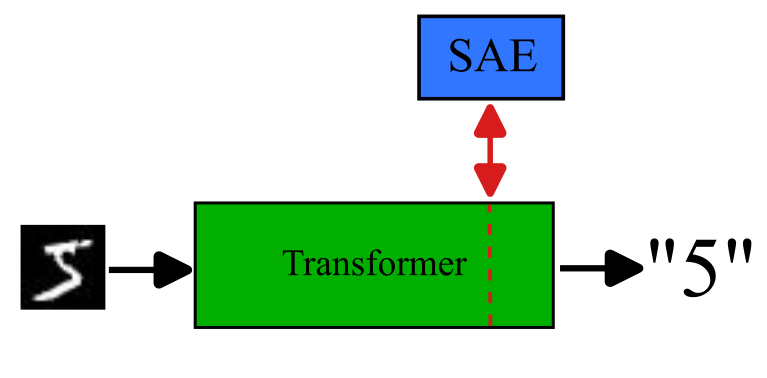

# Entraînement, probing, intervention avec SAE

## Mettre les choses en place

In [ ]:
%%capture
!pip install datasets

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import random
from datasets import load_dataset
import numpy as np

## Le MNIST

MNIST (Modified National Institute of Standards and Technology) est un jeu de données emblématique en apprentissage automatique, introduit en 1998 par Yann LeCun, Corinna Cortes et Christopher Burges. Il consiste en 70 000 images en niveaux de gris de chiffres manuscrits (0 à 9), chacune de taille 28x28 pixels. Le jeu est divisé en 60 000 images d'entraînement et 10 000 images de test.

MNIST a joué un rôle crucial dans le développement de techniques de reconnaissance de formes et reste un ``"Hello World"`` de l'apprentissage profond.

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

mnist/train-00000-of-00001.parquet:   0%|          | 0.00/15.6M [00:00<?, ?B/s]

mnist/test-00000-of-00001.parquet:   0%|          | 0.00/2.60M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/60000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/60000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

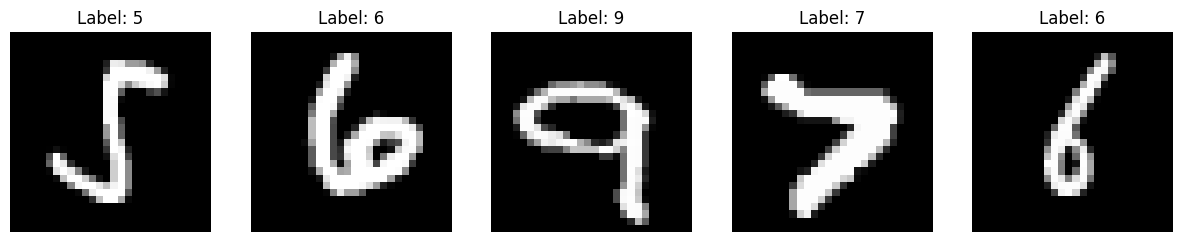

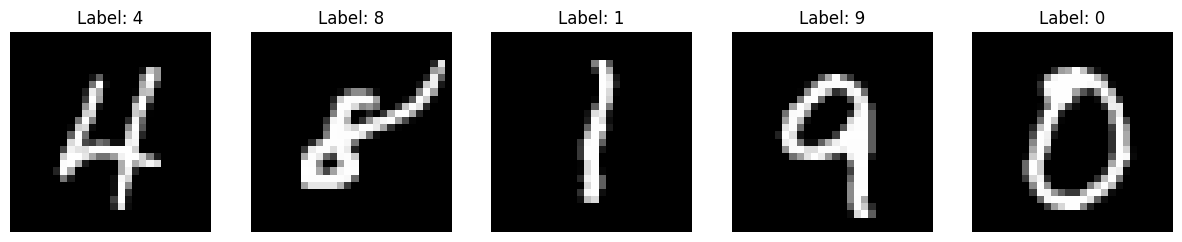

In [ ]:
# Chargement et préparation du dataset
dataset = load_dataset("mnist")
train_dataset = dataset["train"]
test_dataset = dataset["test"]

def preprocess(examples):
    examples["pixel_values"] = [torch.tensor(np.array(img), dtype=torch.float32).view(1, 28, 28) / 255.0
                                for img in examples["image"]]
    return examples

train_dataset = train_dataset.map(preprocess, batched=True, remove_columns=["image"])
test_dataset = test_dataset.map(preprocess, batched=True, remove_columns=["image"])
train_dataset.set_format(type="torch", columns=["pixel_values", "label"])
test_dataset.set_format(type="torch", columns=["pixel_values", "label"])

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Fonction pour afficher des échantillons
def show_samples(dataset, num_samples=5):
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))
    for i in range(num_samples):
        idx = np.random.randint(len(dataset))
        img = dataset[idx]["pixel_values"].squeeze().numpy()
        label = dataset[idx]["label"]
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f"Label: {label}")
        axes[i].axis('off')
    plt.show()

# Afficher des échantillons du jeu d'entraînement
show_samples(train_dataset)

# Afficher des échantillons du jeu de test
show_samples(test_dataset)

## Le Transformer

Qu'est-ce qu'un Transformer ? C'est une architecture assez complexe de modèle, qui comprend trois étapes principales :

Le plongement (ou *embedding*) des mots dans des espaces en grande dimension. Concrètement, chaque mot se voit associer un vecteur qui vit dans un espace de grande dimension $\mathbb{R}^n$. Ces vecteurs sont appris durant l'entraînement. Cela permet en quelque sorte d'encoder la *sémantique* de chaque mot. Soit $w$ un mot, son plongement $e_w$ est défini par :

$$e_w = E[w]$$

où $E$ est la matrice de plongement apprise.

Le mécanisme d'attention, qui permet de calculer les dépendances entre les différents mots d'une phrase. Ce sont trois matrices $Q$, $K$ et $V$ qui sont apprises durant l'entraînement, et qui permettent de projeter l'importance relative des mots précédents sur le suivant. L'attention est calculée comme suit :

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

où $d_k$ est la dimension de la matrice $K$.

Le perceptron multi-couche, qui permet de manipuler les concepts abstraits. C'est un réseau de neurones on ne peut plus classique, entièrement connecté, traditionnellement à deux couches et faisant quatre fois la taille du plongement. Sa fonction peut être représentée comme :

$$\text{FFN}(x) = \max(0, xW_1 + b_1)W_2 + b_2$$

où $W_1$, $W_2$, $b_1$, et $b_2$ sont les paramètres appris.

In [ ]:
# Paramètres
batch_size = 1024
num_epochs = 5
learning_rate = 0.001
d_model = 64
nhead = 2
num_layers = 2

Quelques mots sur ces paramètres, appelés *hyper-paramètres* :

* La taille du lot (``batch_size``) désigne combien d'exemples notre Transformer va voir en parallèle à chaque étape d'entraînement. Ici 1024 exemples.
* Le nombre d'époques (``num_epochs``) désigne le nombre de fois où le jeu de données en entier est vu par le modèle. Ici il va voir 5 fois le jeu de données au complet.
* Le taux d'apprentissage (``learning_rate``) désigne quelle est la force de l'apprentissage, c'est un paramètre multiplicatif devant le gradient.
* La dimension du modèle transformer (``d_model``) désigne la dimension des vecteurs d'embedding, mais donc aussi lors des différentes normalisations.
* Le nombre de têtes d'attention (``nhead``) désigne le nombre de mécanismes d'attention appris en parallèle. Deux têtes signifie qu'il y deux matrices $Q$, deux matrices $K$, et deux matrices $V$.
* Le nombre de couches (``num_layers``) désigne le nombre de fois où l'on répète un transformer, l'un à la suite de l'autre, ici deux fois.

In [ ]:
# Modèle Transformer
class MNISTTransformer(nn.Module):
    def __init__(self, d_model, nhead, num_layers, num_classes=10):
        super(MNISTTransformer, self).__init__()
        self.embedding = nn.Linear(28*28, d_model)
        self.pos_encoder = nn.Parameter(torch.randn(1, d_model))
        self.transformer_layers = nn.ModuleList([
            nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
            for _ in range(num_layers)
        ])
        self.fc = nn.Linear(d_model, num_classes)

    def forward(self, x, return_activations=False):
        x = x.view(x.size(0), -1)  # Aplatir l'image (batch_size, 784)
        x = self.embedding(x)  # (batch_size, d_model)
        x = x + self.pos_encoder  # Diffusion du pos_encoder
        x = x.unsqueeze(1)  # Ajouter une dimension de séquence (batch_size, 1, d_model)

        activations = None
        for i, layer in enumerate(self.transformer_layers):
            x = layer(x)
            if i == 1 and return_activations:
                activations = x.clone()

        x = x.squeeze(1)  # Retirer la dimension de séquence (batch_size, d_model)
        x = self.fc(x)

        if return_activations:
            return x, activations
        return x

## Le SAE

Qu'est-ce qu'un SAE ? En français *Auto-Encodeur Parcimonieux*, le SAE est un modèle qui prend en entrée une donnée $x$, et doit rendre la même donnée en sortie $\hat{x}$ (d'où le "Auto"). L'idée derrière ce modèle est qu'il encode l'information contenue dans la donnée, en tout cas sa *substantifique moelle*, dans une représentation cachée $h$.

Mathématiquement, cela peut s'exprimer comme :

$$h = f(x) = \sigma(Wx + b)$$
$$\hat{x} = g(h) = \sigma(W'h + b')$$

où $f$ est la fonction d'encodage et $g$ la fonction de décodage.

La parcimonie garantit que la solution trouvée sera très simple, appliquant ainsi le *rasoir d'Occam*, qui nous dit de privilégier les solutions simples lorsque plusieurs solutions s'offrent à nous. Cette parcimonie est obtenue en ajoutant un terme de régularisation $\Omega(h)$ à la fonction de perte (*loss*) :

$$\min_{W, W', b, b'} L(x, \hat{x}) + \lambda \Omega(h)$$

où $L$ est une fonction de perte mesurant la différence (distance) entre l'entrée et la sortie reconstruite, et $\lambda$ contrôle le degré de parcimonie.

Nous avons donc une couche linéaire pour encoder l'information, et une couche linéaire pour la décoder.

In [ ]:
sae_hidden_dim = 100 # Une dimension qui doit impérativement être un carré, pour la visualisation

Pour résumer le SAE, nous avons donc :

* Une couche d'entrée de la dimension d'une couche du Transformer qu'on a défini plus haut, c'est-à-dire 64
* Une transformation linéaire qui prend cette entrée et qui rend :
* Une couche cachée, celle qui nous intéresse pour le code, car elle encode l'information de l'entrée, de dimension 100
* Une transformation linéaire qui prend cet encodage et qui rend :
* Un décodage, qui est de taille 64 comme l'entrée, et qui doit en principe lui ressembler le plus possible

In [ ]:
# Modèle SAE
class SparseAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(SparseAutoencoder, self).__init__()
        self.encoder = nn.Linear(input_dim, hidden_dim)
        self.decoder = nn.Linear(hidden_dim, input_dim)

    def forward(self, x):
        encoded = torch.relu(self.encoder(x))
        decoded = self.decoder(encoded)
        return decoded, encoded

## L'entraînement

Cette fonction a pour but d'évaluer à quel point le Transformer prédit bien les étiquettes associées aux images du MNIST. C'est un fonction de précision, et ce qu'elle rend est un pourcentage d'exemples correctement classifiés.

In [ ]:
# Fonction d'évaluation pour le Transformer
def evaluate_transformer(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in data_loader:
            inputs, labels = batch['pixel_values'].to(device), batch['label'].to(device)
            outputs, _ = model(inputs, return_activations=True)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_loss = total_loss / len(data_loader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy

Le critère de la fonction de perte pour le Transformer est l'entropie croisée (``nn.CrossEntropyLoss()``), qui permet de calculer la distance entre deux distributions. Dans ce contexte, nous comparons :

1. La distribution attendue, qui est une distribution certaine puisqu'une seule étiquette est prévue pour chaque image. Elle est représentée par un vecteur unitaire $y$ (*one-hot encoding*) :

   $$y = (0, 0, ..., 1, ..., 0)$$

2. La distribution à la sortie du Transformer, que nous appellerons $\hat{y}$ :

   $$\hat{y} = (\hat{y}_1, \hat{y}_2, ..., \hat{y}_n)$$

   où $n$ est le nombre de classes possibles.

L'entropie croisée entre ces deux distributions est définie comme suit :

$$H(y, \hat{y}) = -\sum_{i=1}^n y_i \log(\hat{y}_i)$$

Dans le cas d'une distribution certaine (*one-hot encoding*), ce qui est le cas ici, cette formule se simplifie à :

$$H(y, \hat{y}) = -\log(\hat{y}_c)$$

où $c$ est l'indice de la classe correcte.

L'objectif de l'entraînement est de minimiser cette entropie croisée, ce qui revient à maximiser la probabilité que le modèle assigne à la classe correcte.

In [ ]:
# Initialisation des modèles
transformer = MNISTTransformer(d_model, nhead, num_layers)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(transformer.parameters(), lr=learning_rate)

# Entraînement du Transformer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transformer.to(device)

MNISTTransformer(
  (embedding): Linear(in_features=784, out_features=64, bias=True)
  (transformer_layers): ModuleList(
    (0-1): 2 x TransformerEncoderLayer(
      (self_attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
      )
      (linear1): Linear(in_features=64, out_features=2048, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (linear2): Linear(in_features=2048, out_features=64, bias=True)
      (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (dropout1): Dropout(p=0.1, inplace=False)
      (dropout2): Dropout(p=0.1, inplace=False)
    )
  )
  (fc): Linear(in_features=64, out_features=10, bias=True)
)

In [ ]:
for epoch in range(num_epochs):
    transformer.train()
    total_loss = 0
    for batch in train_loader:
        inputs, labels = batch['pixel_values'].to(device), batch['label'].to(device)

        optimizer.zero_grad()
        outputs, _ = transformer(inputs, return_activations=True)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)

    # Évaluation sur l'ensemble de test
    test_loss, test_accuracy = evaluate_transformer(transformer, test_loader, criterion, device)

    print(f"Transformer Epoch [{epoch+1}/{num_epochs}]")
    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%")

print("Entraînement du Transformer terminé!")

Transformer Epoch [1/5]
  Train Loss: 0.3148
  Test Loss: 0.1609, Test Accuracy: 95.13%
Transformer Epoch [2/5]
  Train Loss: 0.1451
  Test Loss: 0.1290, Test Accuracy: 96.24%
Transformer Epoch [3/5]
  Train Loss: 0.1107
  Test Loss: 0.0871, Test Accuracy: 97.48%
Transformer Epoch [4/5]
  Train Loss: 0.0875
  Test Loss: 0.0965, Test Accuracy: 97.14%
Transformer Epoch [5/5]
  Train Loss: 0.0750
  Test Loss: 0.0844, Test Accuracy: 97.47%
Entraînement du Transformer terminé!


Une fois le transformer entraîné, on collecte les activations de la couche de MLP, c'est à dire les états des vecteurs lorsqu'on donne une image du MNIST à notre Transformer. C'est comme si on prenait un instantané de la pensée de notre Transformer.

In [ ]:
# Collecter les activations
transformer.eval()
activations = []
with torch.no_grad():
    for batch in train_loader:
        inputs = batch['pixel_values'].to(device)
        _, batch_activations = transformer(inputs, return_activations=True)
        activations.append(batch_activations.squeeze(1).cpu())

activations = torch.cat(activations, dim=0)

Avec ces activations, on peut entraîner notre SAE, qui va s'efforcer de rendre la même activation, en l'encodant avec le moins de neurones activés possible (la plupart vaut zéro comme on le verra).

In [ ]:
# Fonction d'entraînement du SAE
def train_sae(sae, activation_loader, num_epochs=300, learning_rate=0.001, sparsity_weight=0.1):
    optimizer = optim.Adam(sae.parameters(), lr=learning_rate)
    criterion = nn.MSELoss()

    for epoch in range(num_epochs):
        total_loss = 0
        for batch in activation_loader:
            batch = batch[0].to(device)
            optimizer.zero_grad()
            decoded, encoded = sae(batch)
            reconstruction_loss = criterion(decoded, batch)
            sparsity_loss = torch.mean(torch.abs(encoded))
            loss = reconstruction_loss + sparsity_weight * sparsity_loss
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"SAE Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss/len(activation_loader):.4f}")


In [ ]:
# Initialiser et entraîner le SAE
sae = SparseAutoencoder(d_model, sae_hidden_dim)
sae.to(device)
activation_dataset = TensorDataset(activations)
activation_loader = DataLoader(activation_dataset, batch_size=batch_size, shuffle=True)
train_sae(sae, activation_loader)

print("Entraînement du SAE terminé!")

SAE Epoch [1/300], Loss: 0.5661
SAE Epoch [2/300], Loss: 0.0721
SAE Epoch [3/300], Loss: 0.0597
SAE Epoch [4/300], Loss: 0.0524
SAE Epoch [5/300], Loss: 0.0467
SAE Epoch [6/300], Loss: 0.0421
SAE Epoch [7/300], Loss: 0.0384
SAE Epoch [8/300], Loss: 0.0353
SAE Epoch [9/300], Loss: 0.0326
SAE Epoch [10/300], Loss: 0.0304
SAE Epoch [11/300], Loss: 0.0284
SAE Epoch [12/300], Loss: 0.0267
SAE Epoch [13/300], Loss: 0.0252
SAE Epoch [14/300], Loss: 0.0239
SAE Epoch [15/300], Loss: 0.0227
SAE Epoch [16/300], Loss: 0.0216
SAE Epoch [17/300], Loss: 0.0206
SAE Epoch [18/300], Loss: 0.0196
SAE Epoch [19/300], Loss: 0.0188
SAE Epoch [20/300], Loss: 0.0180
SAE Epoch [21/300], Loss: 0.0173
SAE Epoch [22/300], Loss: 0.0166
SAE Epoch [23/300], Loss: 0.0160
SAE Epoch [24/300], Loss: 0.0154
SAE Epoch [25/300], Loss: 0.0148
SAE Epoch [26/300], Loss: 0.0143
SAE Epoch [27/300], Loss: 0.0138
SAE Epoch [28/300], Loss: 0.0133
SAE Epoch [29/300], Loss: 0.0129
SAE Epoch [30/300], Loss: 0.0125
SAE Epoch [31/300],

## Visualisation

Ce code permet de visualiser toutes les étapes intéressantes.

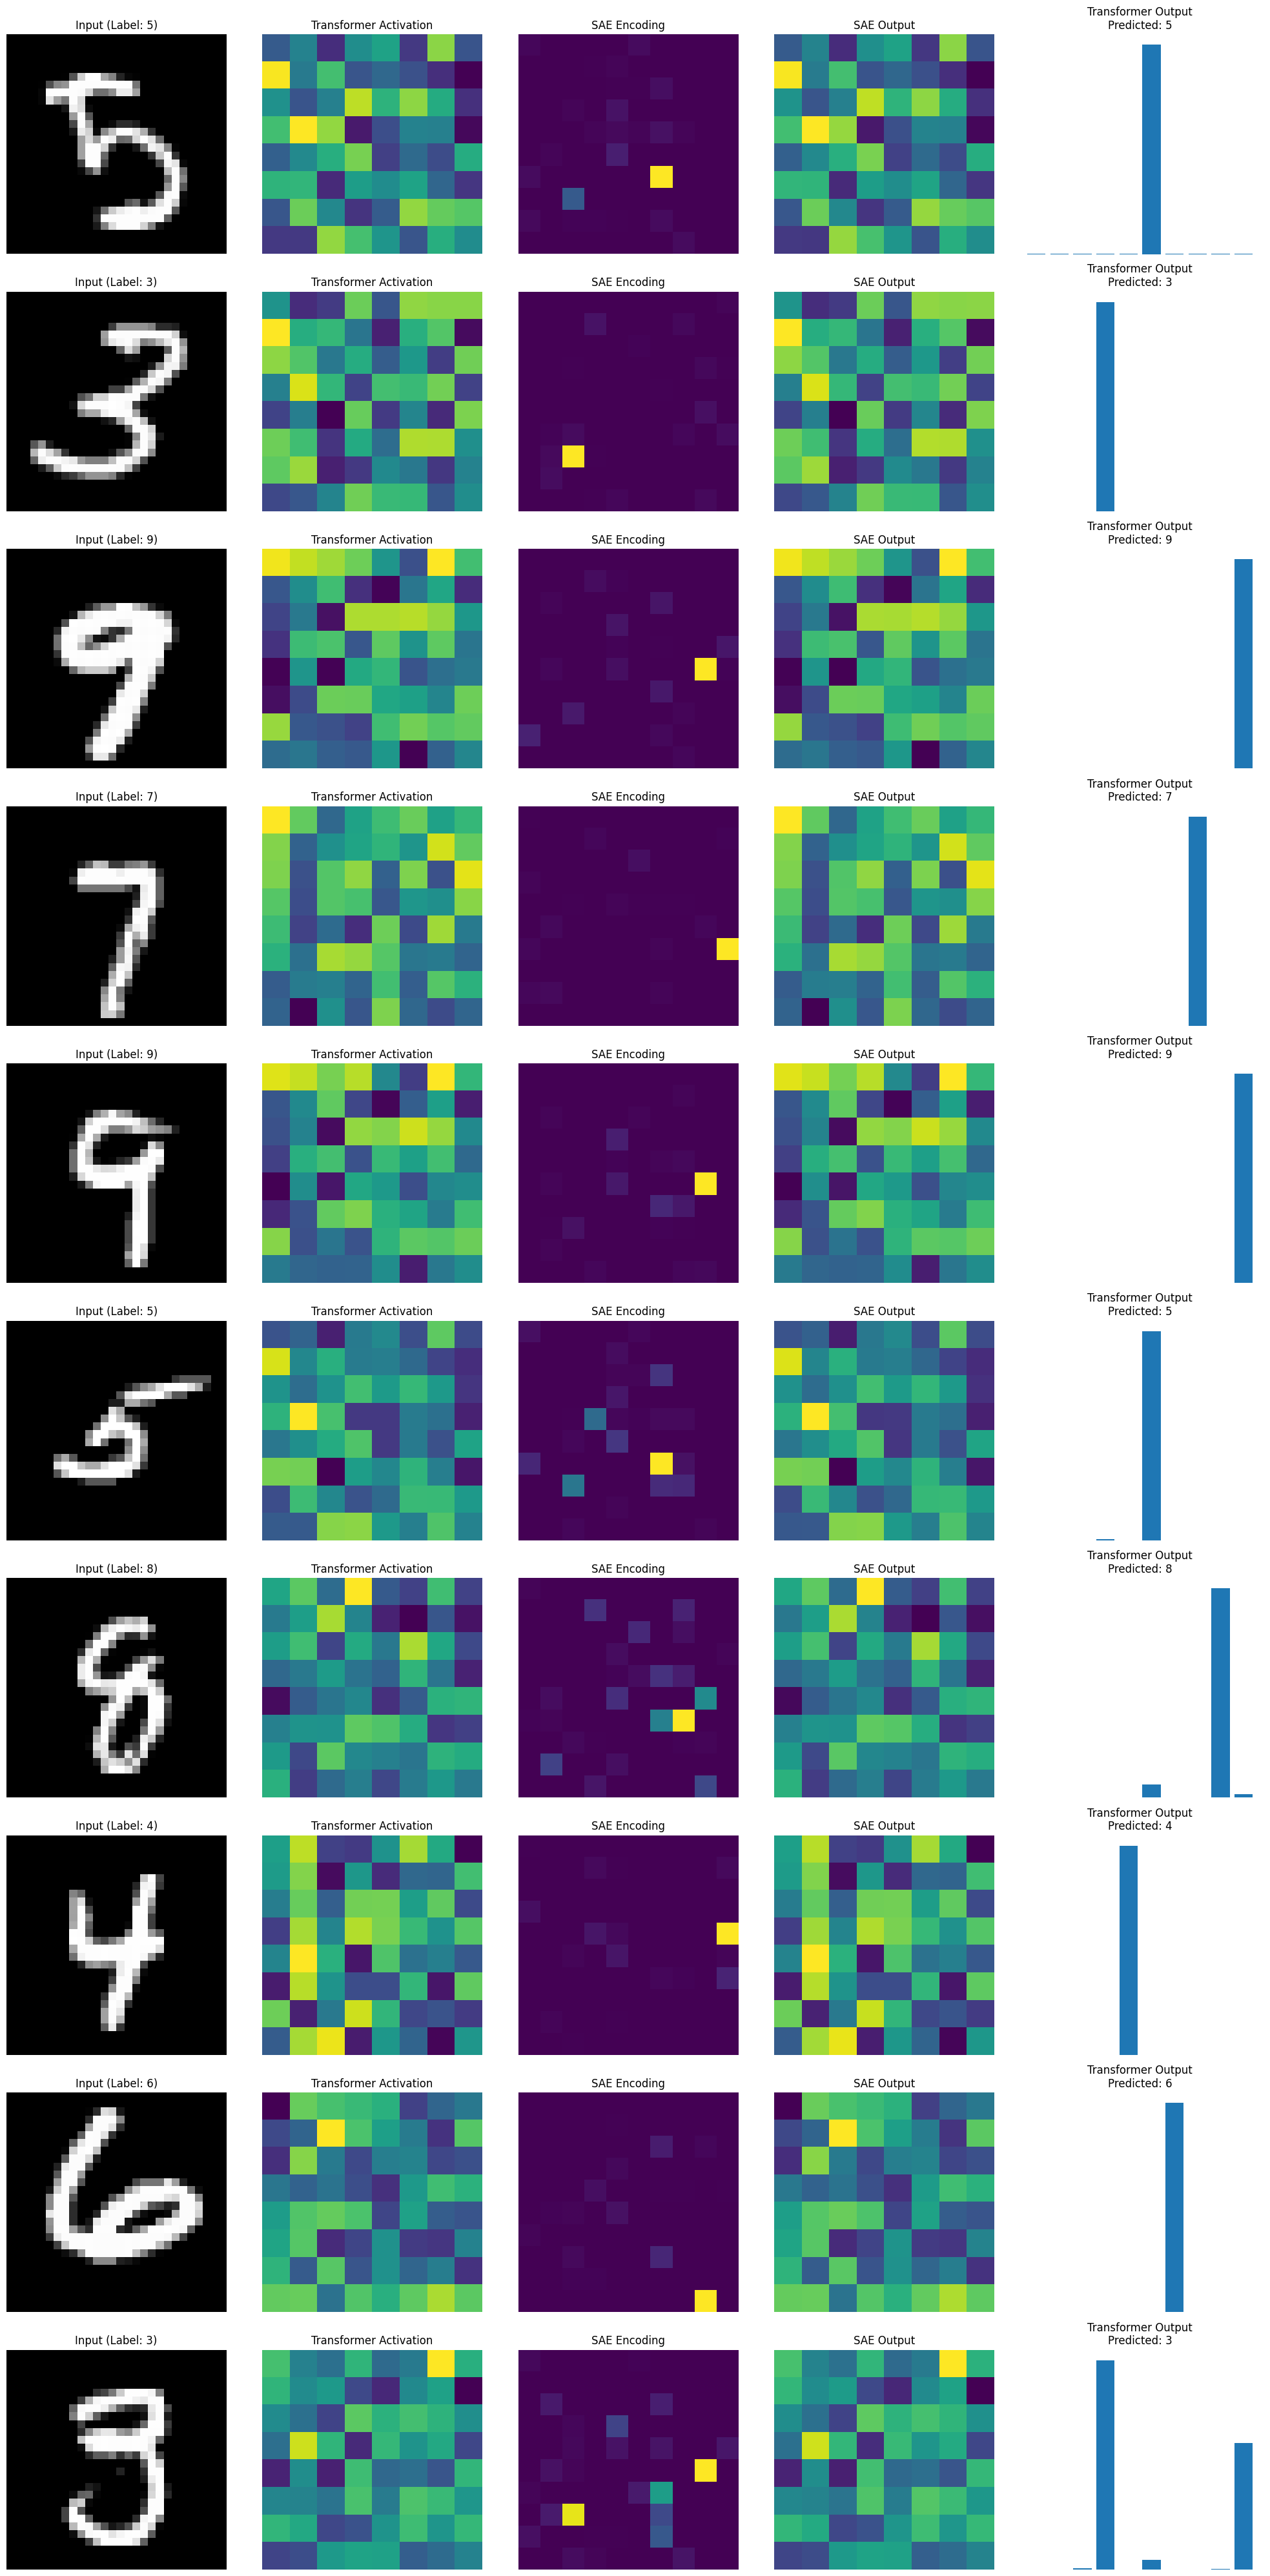

In [ ]:
def visualize_process(transformer, sae, test_loader, num_samples=10):
    device = next(transformer.parameters()).device
    transformer.eval()
    sae.eval()

    # Sélectionner des échantillons aléatoires
    all_samples = []
    for batch in test_loader:
        all_samples.extend(list(zip(batch['pixel_values'], batch['label'])))
    random_samples = random.sample(all_samples, num_samples)

    fig, axs = plt.subplots(num_samples, 5, figsize=(20, 4*num_samples))

    for i, (image, label) in enumerate(random_samples):
        image = image.to(device)

        # Image originale
        axs[i, 0].imshow(image.cpu().squeeze().numpy(), cmap='gray')
        axs[i, 0].set_title(f"Input (Label: {label})")

        # Transformer activation
        with torch.no_grad():
            transformer_output = transformer(image.unsqueeze(0), return_activations=True)
            transformer_activation = transformer_output[-1].squeeze().cpu()

        # SAE encoding et decoding
        with torch.no_grad():
            sae_output, sae_encoding = sae(transformer_activation.to(device))

        # Affichage de l'activation du Transformer
        axs[i, 1].imshow(transformer_activation.numpy().reshape(int(np.sqrt(transformer_activation.shape[0])), -1), cmap='viridis')
        axs[i, 1].set_title("Transformer Activation")

        # Affichage de l'encodage SAE
        axs[i, 2].imshow(sae_encoding.cpu().numpy().reshape(int(np.sqrt(sae_encoding.shape[0])), -1), cmap='viridis')
        axs[i, 2].set_title("SAE Encoding")

        # Affichage de la sortie SAE
        axs[i, 3].imshow(sae_output.cpu().numpy().reshape(int(np.sqrt(sae_output.shape[0])), -1), cmap='viridis')
        axs[i, 3].set_title("SAE Output")

        # Affichage de la sortie du Transformer
        with torch.no_grad():
            transformer_output = transformer(image.unsqueeze(0))
        predicted_class = torch.argmax(transformer_output).item()
        axs[i, 4].bar(range(10), nn.functional.softmax(transformer_output.squeeze(), dim=0).cpu().numpy())
        axs[i, 4].set_title(f"Transformer Output\nPredicted: {predicted_class}")
        axs[i, 4].set_xticks(range(10))

    for ax in axs.flat:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Utilisation de la fonction
visualize_process(transformer, sae, test_loader)

Description :

* première colonne : input du transformer
* deuxième : état de la couche de sortie du MLP dans le transformer
* troisième : état de la couche de code du SAE, qui a été entraîné sur ladite couche de sortie du MLP
* quatrième : couche prédite par le SAE après décodage (identique à l'entrée donc)
* cinquième : output du transformer, c'est-à dire une distribution sur les labels des chiffres. Tellement bien entraîné qu'il est souvent certain...

## Chirurgie du Transformer ! (à vous de jouer)

Voici le code qui permet d'intervenir directement sur les neurones, et qui permet de modifier le "flux de pensée" du Transformer : on peut lui faire croire qu'il voit un 0 alors qu'il a un autre chiffre en entrée !

In [ ]:
def visualize_process_with_intervention(transformer, sae, test_loader, num_samples=20, neuron_position=None, intensity=1.0):
    device = next(transformer.parameters()).device
    transformer.eval()
    sae.eval()

    all_samples = []
    for batch in test_loader:
        all_samples.extend(list(zip(batch['pixel_values'], batch['label'])))
    random_samples = random.sample(all_samples, num_samples)

    fig, axs = plt.subplots(num_samples, 7, figsize=(28, 4*num_samples))
    fig.suptitle(f"Visualisation du processus Transformer-SAE avec intervention (Neurone: {neuron_position}, Intensité: {intensity})", fontsize=16)

    for i, (image, label) in enumerate(random_samples):
        image = image.to(device)

        # Image originale
        axs[i, 0].imshow(image.cpu().squeeze().numpy(), cmap='gray')
        axs[i, 0].set_title(f"Input (Label: {label})")

        # Transformer activation
        with torch.no_grad():
            original_output, transformer_activation = transformer(image.unsqueeze(0), return_activations=True)
            transformer_activation = transformer_activation.squeeze().cpu()

        # SAE encoding et decoding
        with torch.no_grad():
            sae_output, sae_encoding = sae(transformer_activation.to(device))

        # Affichage de l'activation du Transformer
        axs[i, 1].imshow(transformer_activation.numpy().reshape(int(np.sqrt(transformer_activation.shape[0])), -1), cmap='viridis')
        axs[i, 1].set_title("Transformer Activation")

        # Affichage de l'encodage SAE original
        axs[i, 2].imshow(sae_encoding.cpu().numpy().reshape(int(np.sqrt(sae_encoding.shape[0])), -1), cmap='viridis')
        axs[i, 2].set_title("SAE Encoding (Original)")

        # Intervention manuelle sur l'encodage SAE
        modified_encoding = sae_encoding.clone()
        if neuron_position is not None:
            modified_encoding[neuron_position] += intensity
        else:
            # Si aucun neurone spécifique n'est choisi, on modifie le premier quart comme avant
            region_size = sae_encoding.shape[0] // 4
            modified_encoding[:region_size] *= intensity

        # Affichage de l'encodage SAE modifié
        axs[i, 3].imshow(modified_encoding.cpu().numpy().reshape(int(np.sqrt(modified_encoding.shape[0])), -1), cmap='viridis')
        axs[i, 3].set_title("SAE Encoding (Modified)")

        # Décodage de l'encodage modifié
        with torch.no_grad():
            modified_output = sae.decoder(modified_encoding.to(device))

        # Affichage de la sortie SAE modifiée
        axs[i, 4].imshow(modified_output.cpu().numpy().reshape(int(np.sqrt(modified_output.shape[0])), -1), cmap='viridis')
        axs[i, 4].set_title("Modified SAE Output")

        # Affichage de la sortie du Transformer original
        original_predicted_class = torch.argmax(original_output).item()
        axs[i, 5].bar(range(10), nn.functional.softmax(original_output.squeeze(), dim=0).cpu().numpy())
        axs[i, 5].set_title(f"Original Output\nPredicted: {original_predicted_class}")
        axs[i, 5].set_xticks(range(10))

        # Calcul de la sortie du Transformer avec intervention
        with torch.no_grad():
            # Préparation des données pour le passage à travers le transformer
            x = image.view(1, -1)  # Aplatir l'image (1, 784)
            x = transformer.embedding(x)  # (1, d_model)
            x = x + transformer.pos_encoder  # Diffusion du pos_encoder
            x = x.unsqueeze(1)  # Ajouter une dimension de séquence (1, 1, d_model)

            # Passage à travers les couches du transformer
            for j, layer in enumerate(transformer.transformer_layers):
                if j == 1:
                    # Remplacer l'activation de la deuxième couche par l'activation modifiée
                    x = modified_output.unsqueeze(0).unsqueeze(0)
                else:
                    x = layer(x)

            x = x.squeeze(1)  # Retirer la dimension de séquence (1, d_model)
            modified_transformer_output = transformer.fc(x)

        modified_predicted_class = torch.argmax(modified_transformer_output).item()
        axs[i, 6].bar(range(10), nn.functional.softmax(modified_transformer_output.squeeze(), dim=0).cpu().numpy())
        axs[i, 6].set_title(f"Modified Output\nPredicted: {modified_predicted_class}")
        axs[i, 6].set_xticks(range(10))

    for ax in axs.flat:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Utilisation de la fonction
# Pour modifier un neurone spécifique, utilisez :
# visualize_process_with_intervention(transformer, sae, test_loader, neuron_position=42, intensity=2.0)
# Pour modifier une région, utilisez :
# visualize_process_with_intervention(transformer, sae, test_loader, intensity=2.0)
# visualize_process_with_intervention(transformer, sae, test_loader)

### Comment persuader un transformer qu'il voit un zéro, alors qu'il a un autre chiffre devant ses yeux ?

Le neurone lié au 0 dans le SAE (lorsque je l'ai entraîné) est le **neurone 28**. L'intensité est fixée à 2, ce qui permet de compenser les autres neurones déjà activer, pour forcer les choses.

Usage : Pour modifier un neurone, mettez `neuron_position` = `index` du neurone que vous voulez triturer, et changez son intensité !

*Note : à chaque entraînement du modèle, la place du neurone change, il faut donc observer attentivement la position du neurone en question dans la sortie au dessus.*

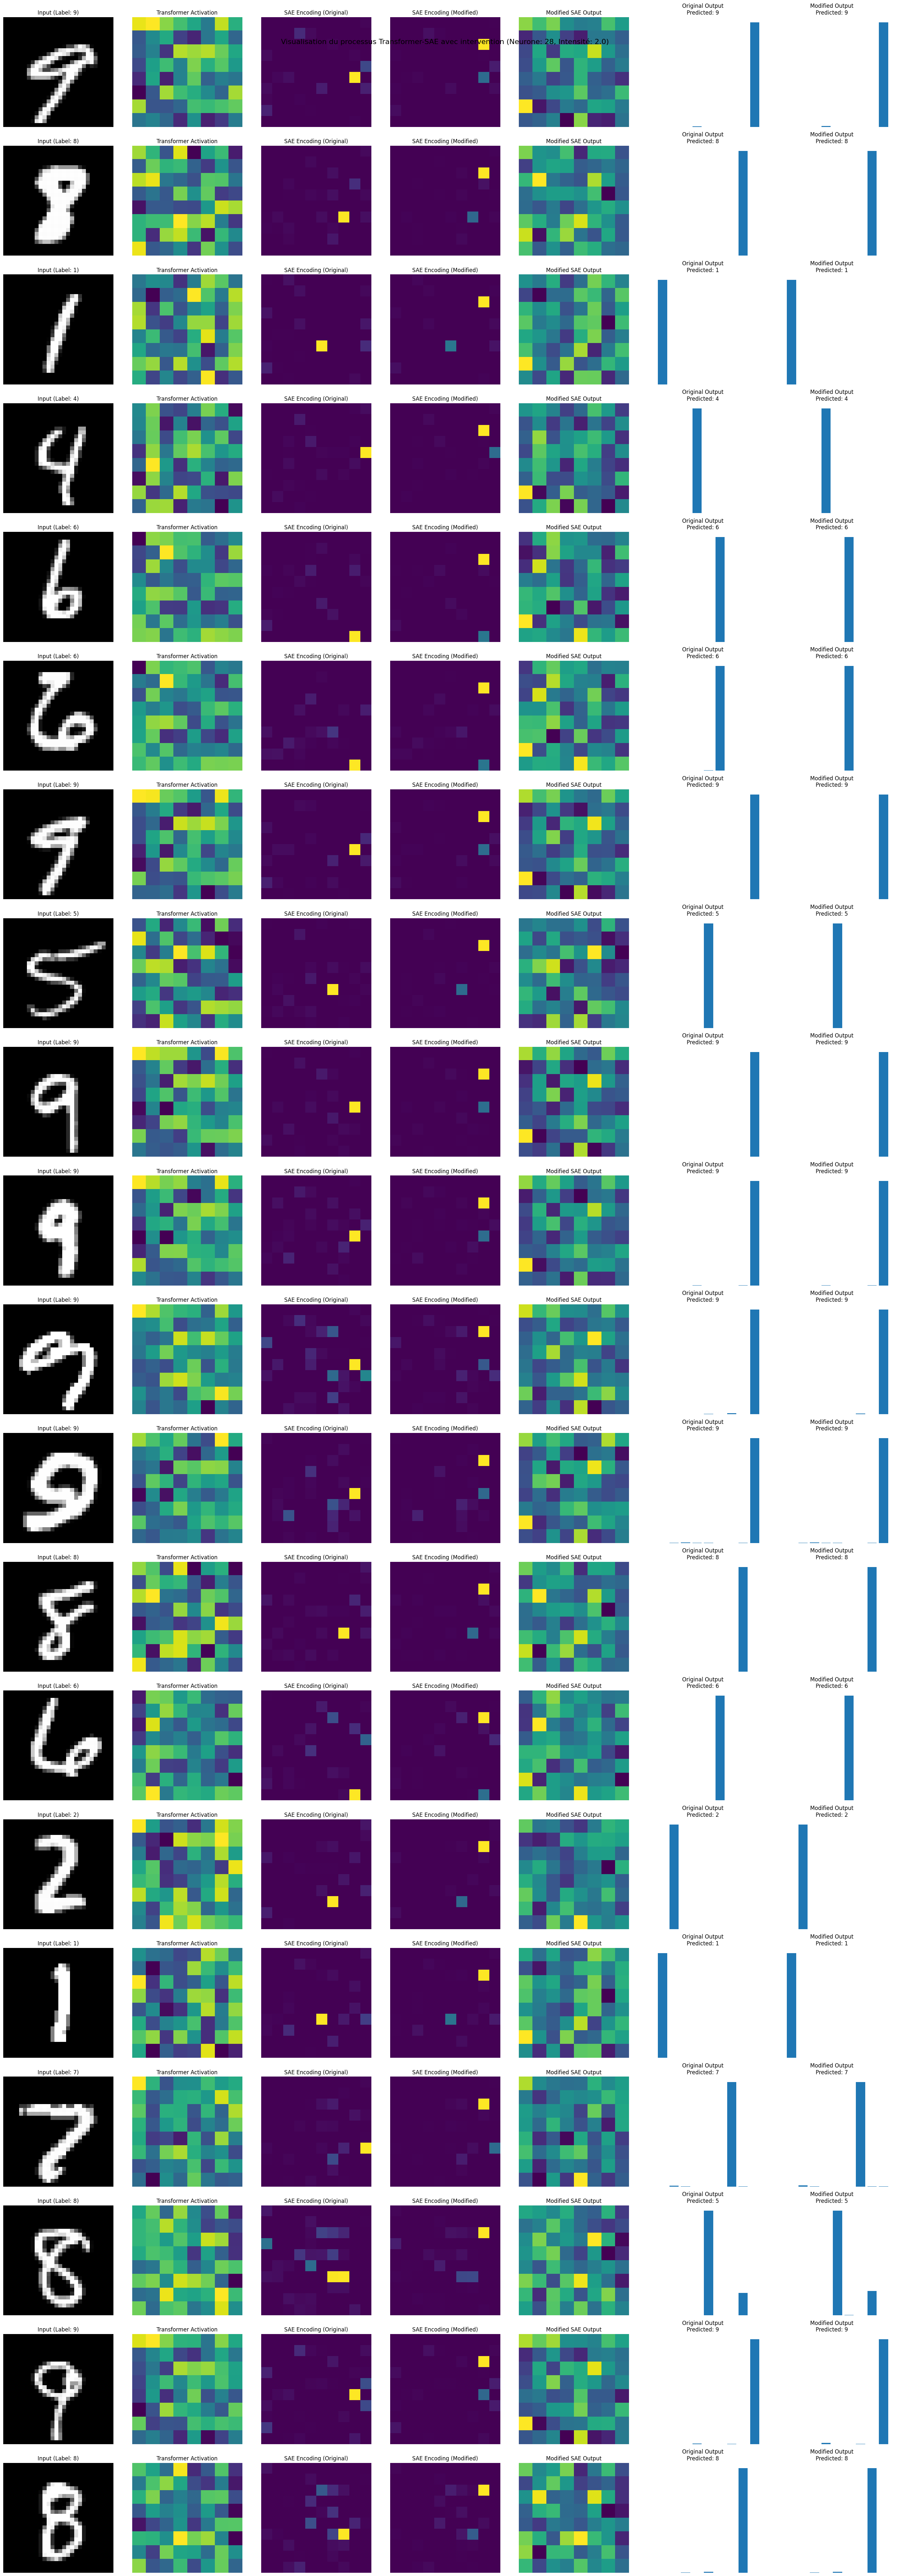

In [ ]:
visualize_process_with_intervention(transformer, sae, test_loader, neuron_position=28, intensity=2.0)

*Et voilà comment on finit par croire qu'on est le Golden Bridge...*

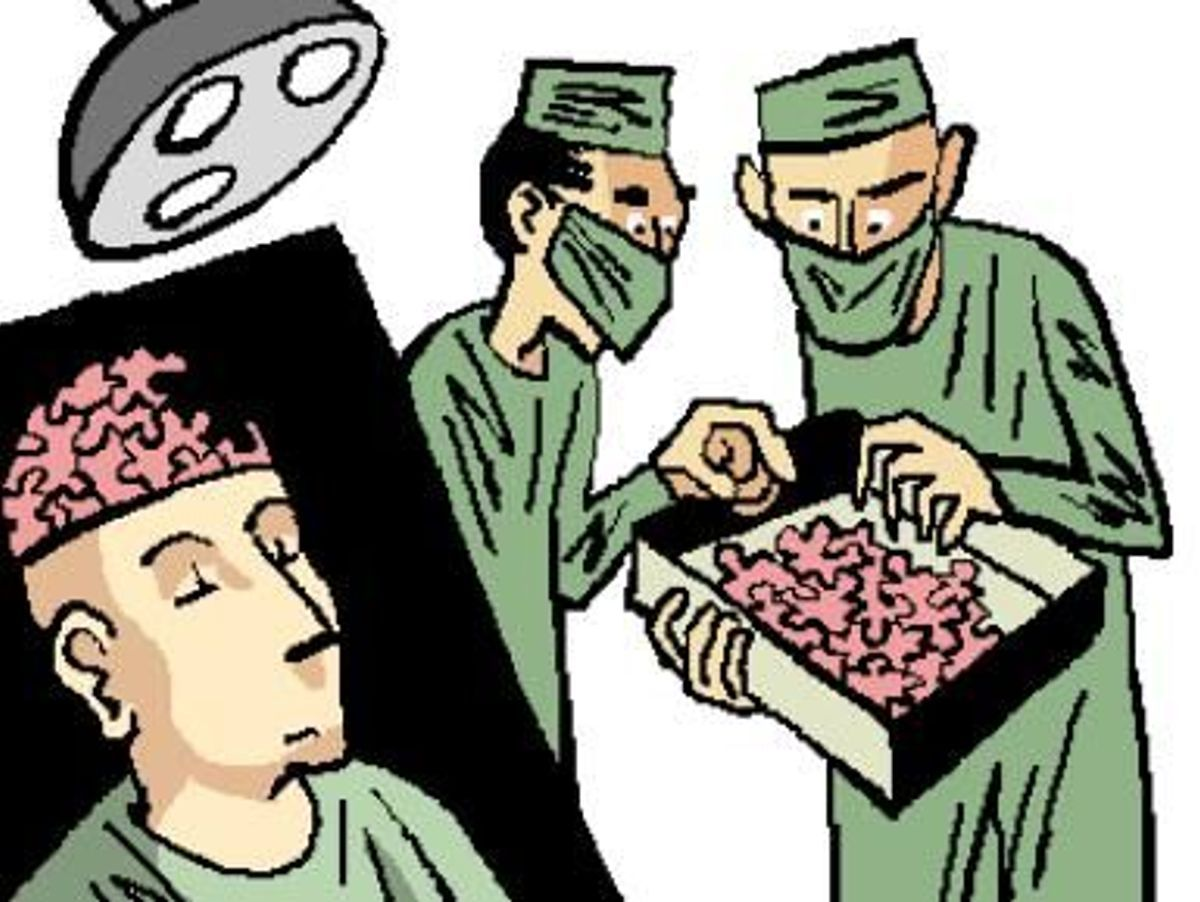

# Meta-SAE (pour aller encore plus loin)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

class MetaSAE(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(MetaSAE, self).__init__()
        self.encoder = nn.Linear(input_dim, hidden_dim)
        self.decoder = nn.Linear(hidden_dim, input_dim)

    def forward(self, x):
        encoded = self.batch_top_k(self.encoder(x), k=4)  # BatchTopK avec k=4
        decoded = self.decoder(encoded)
        return decoded, encoded

    def batch_top_k(self, x, k):
        top_k_values, _ = torch.topk(x, k, dim=1)
        kth_values = top_k_values[:, -1].unsqueeze(1)
        return torch.where(x >= kth_values, x, torch.zeros_like(x))

In [ ]:
def train_meta_sae(meta_sae, sae, num_epochs=2000, learning_rate=0.001, sparsity_weight=0.1):
    optimizer = optim.Adam(meta_sae.parameters(), lr=learning_rate)
    criterion = nn.MSELoss()

    # Obtenir les poids du décodeur du SAE original
    decoder_weights = sae.decoder.weight.t().detach()

    for epoch in range(num_epochs):
        optimizer.zero_grad()

        # Forward pass
        decoded, encoded = meta_sae(decoder_weights)

        # Calcul des pertes
        reconstruction_loss = criterion(decoded, decoder_weights)
        sparsity_loss = torch.mean(torch.abs(encoded))
        loss = reconstruction_loss + sparsity_weight * sparsity_loss

        # Backward pass et optimisation
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 100 == 0:
            print(f"Meta-SAE Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")


In [ ]:
# Créer et entraîner le meta-SAE
input_dim = sae.decoder.weight.shape[0]  # Taille des latents du SAE original
hidden_dim = 100  # Comme dans l'article original
meta_sae = MetaSAE(input_dim, hidden_dim).to(device)
train_meta_sae(meta_sae, sae)

Meta-SAE Epoch [100/2000], Loss: 0.1126
Meta-SAE Epoch [200/2000], Loss: 0.0408
Meta-SAE Epoch [300/2000], Loss: 0.0290
Meta-SAE Epoch [400/2000], Loss: 0.0235
Meta-SAE Epoch [500/2000], Loss: 0.0190
Meta-SAE Epoch [600/2000], Loss: 0.0161
Meta-SAE Epoch [700/2000], Loss: 0.0152
Meta-SAE Epoch [800/2000], Loss: 0.0131
Meta-SAE Epoch [900/2000], Loss: 0.0128
Meta-SAE Epoch [1000/2000], Loss: 0.0120
Meta-SAE Epoch [1100/2000], Loss: 0.0110
Meta-SAE Epoch [1200/2000], Loss: 0.0102
Meta-SAE Epoch [1300/2000], Loss: 0.0100
Meta-SAE Epoch [1400/2000], Loss: 0.0095
Meta-SAE Epoch [1500/2000], Loss: 0.0093
Meta-SAE Epoch [1600/2000], Loss: 0.0092
Meta-SAE Epoch [1700/2000], Loss: 0.0085
Meta-SAE Epoch [1800/2000], Loss: 0.0082
Meta-SAE Epoch [1900/2000], Loss: 0.0083
Meta-SAE Epoch [2000/2000], Loss: 0.0076


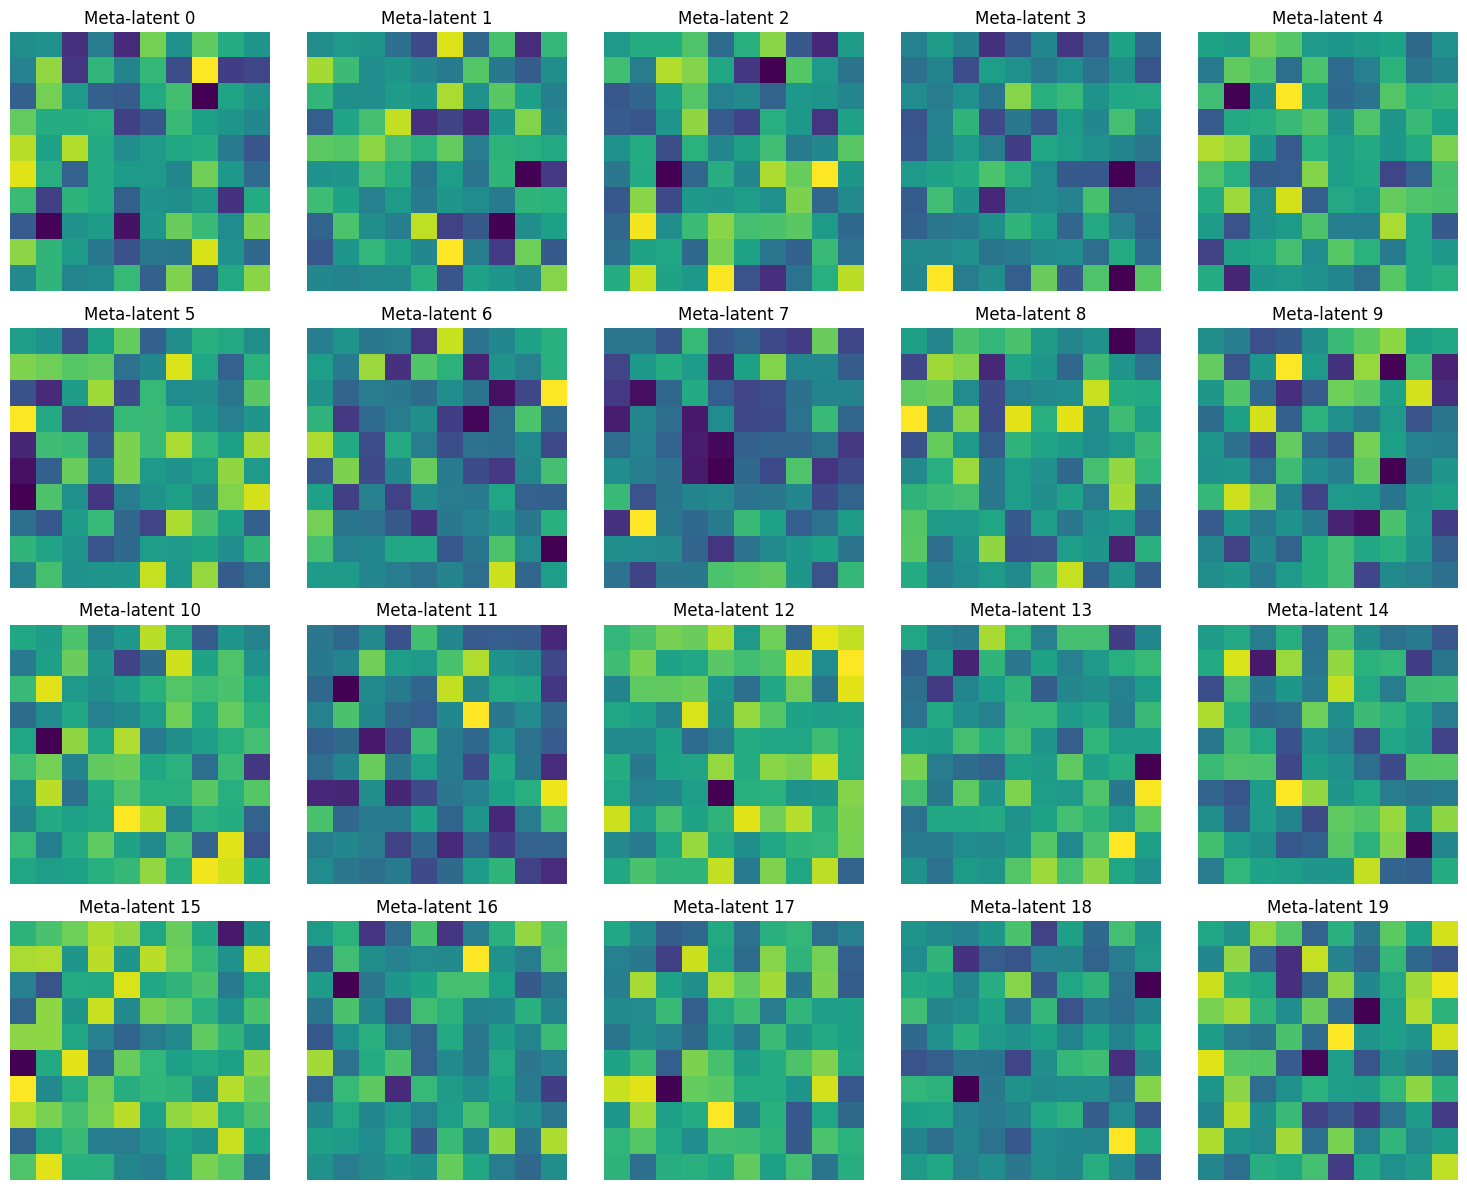

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def visualize_meta_latents(meta_sae, num_latents=10):
    meta_sae.eval()

    # Obtenir les poids du décodeur du meta-SAE
    with torch.no_grad():
        decoder_weights = meta_sae.decoder.weight.t().cpu().numpy()

    # Calculer le nombre de lignes et de colonnes pour le subplot
    num_rows = (num_latents + 4) // 5  # 5 images par ligne
    num_cols = min(num_latents, 5)

    fig, axs = plt.subplots(num_rows, num_cols, figsize=(15, 3*num_rows))
    axs = axs.flatten() if num_rows > 1 else [axs]

    for i in range(num_latents):
        # Redimensionner le poids en image carrée
        img_size = int(np.sqrt(decoder_weights.shape[0]))
        img = decoder_weights[:, i].reshape(img_size, img_size)

        # Afficher l'image
        axs[i].imshow(img, cmap='viridis')
        axs[i].axis('off')
        axs[i].set_title(f'Meta-latent {i}')

    # Cacher les subplots vides
    for i in range(num_latents, len(axs)):
        axs[i].axis('off')

    plt.tight_layout()
    plt.show()

# Appeler la fonction
visualize_meta_latents(meta_sae, num_latents=20)

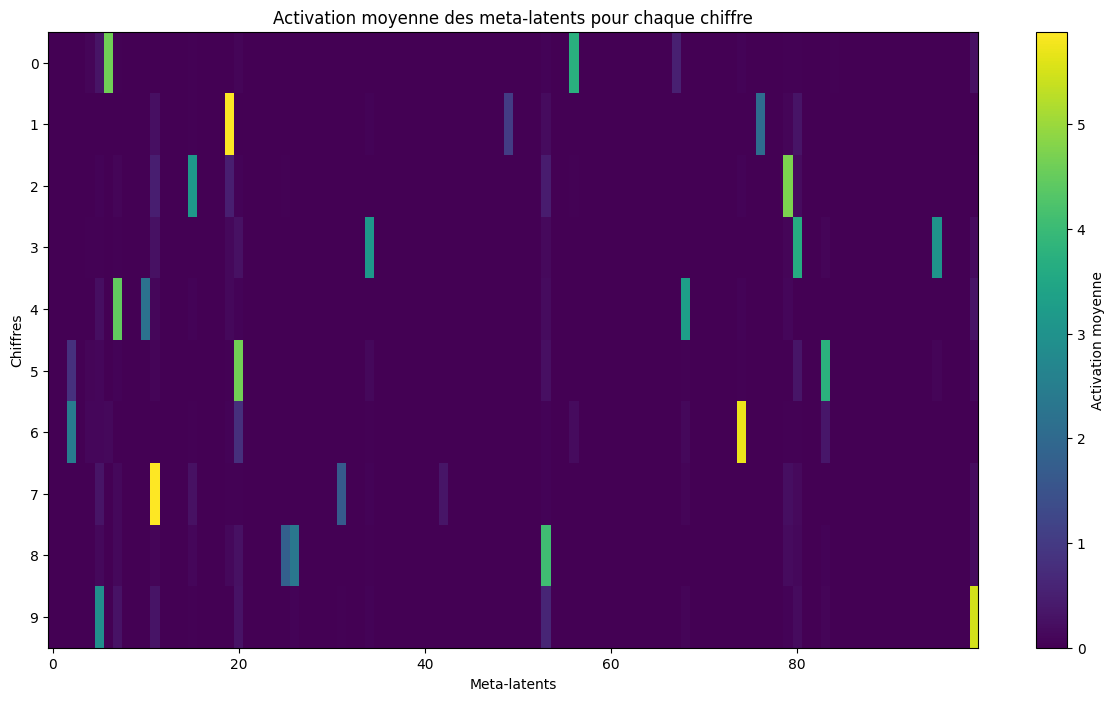

In [ ]:
def analyze_meta_latents_activation(meta_sae, sae, transformer, test_loader, num_samples=1000):
    meta_sae.eval()
    sae.eval()
    transformer.eval()

    all_activations = []
    all_labels = []

    with torch.no_grad():
        for batch in test_loader:
            inputs, labels = batch['pixel_values'].to(device), batch['label']

            if len(all_labels) >= num_samples:
                break

            # Obtenir les activations du transformer
            _, transformer_activations = transformer(inputs, return_activations=True)

            # Passer à travers le SAE
            sae_encoded, _ = sae(transformer_activations.squeeze(1))

            # Passer à travers le meta-SAE
            _, meta_encoded = meta_sae(sae_encoded)

            all_activations.append(meta_encoded.cpu())
            all_labels.extend(labels.numpy())

    all_activations = torch.cat(all_activations, dim=0).numpy()
    all_labels = np.array(all_labels)

    # Calculer l'activation moyenne pour chaque chiffre
    mean_activations = np.array([all_activations[all_labels == i].mean(axis=0) for i in range(10)])

    # Afficher un heatmap des activations moyennes
    plt.figure(figsize=(15, 8))
    plt.imshow(mean_activations, aspect='auto', cmap='viridis')
    plt.colorbar(label='Activation moyenne')
    plt.xlabel('Meta-latents')
    plt.ylabel('Chiffres')
    plt.title('Activation moyenne des meta-latents pour chaque chiffre')
    plt.yticks(range(10))
    plt.show()

# Appeler la fonction
analyze_meta_latents_activation(meta_sae, sae, transformer, test_loader)

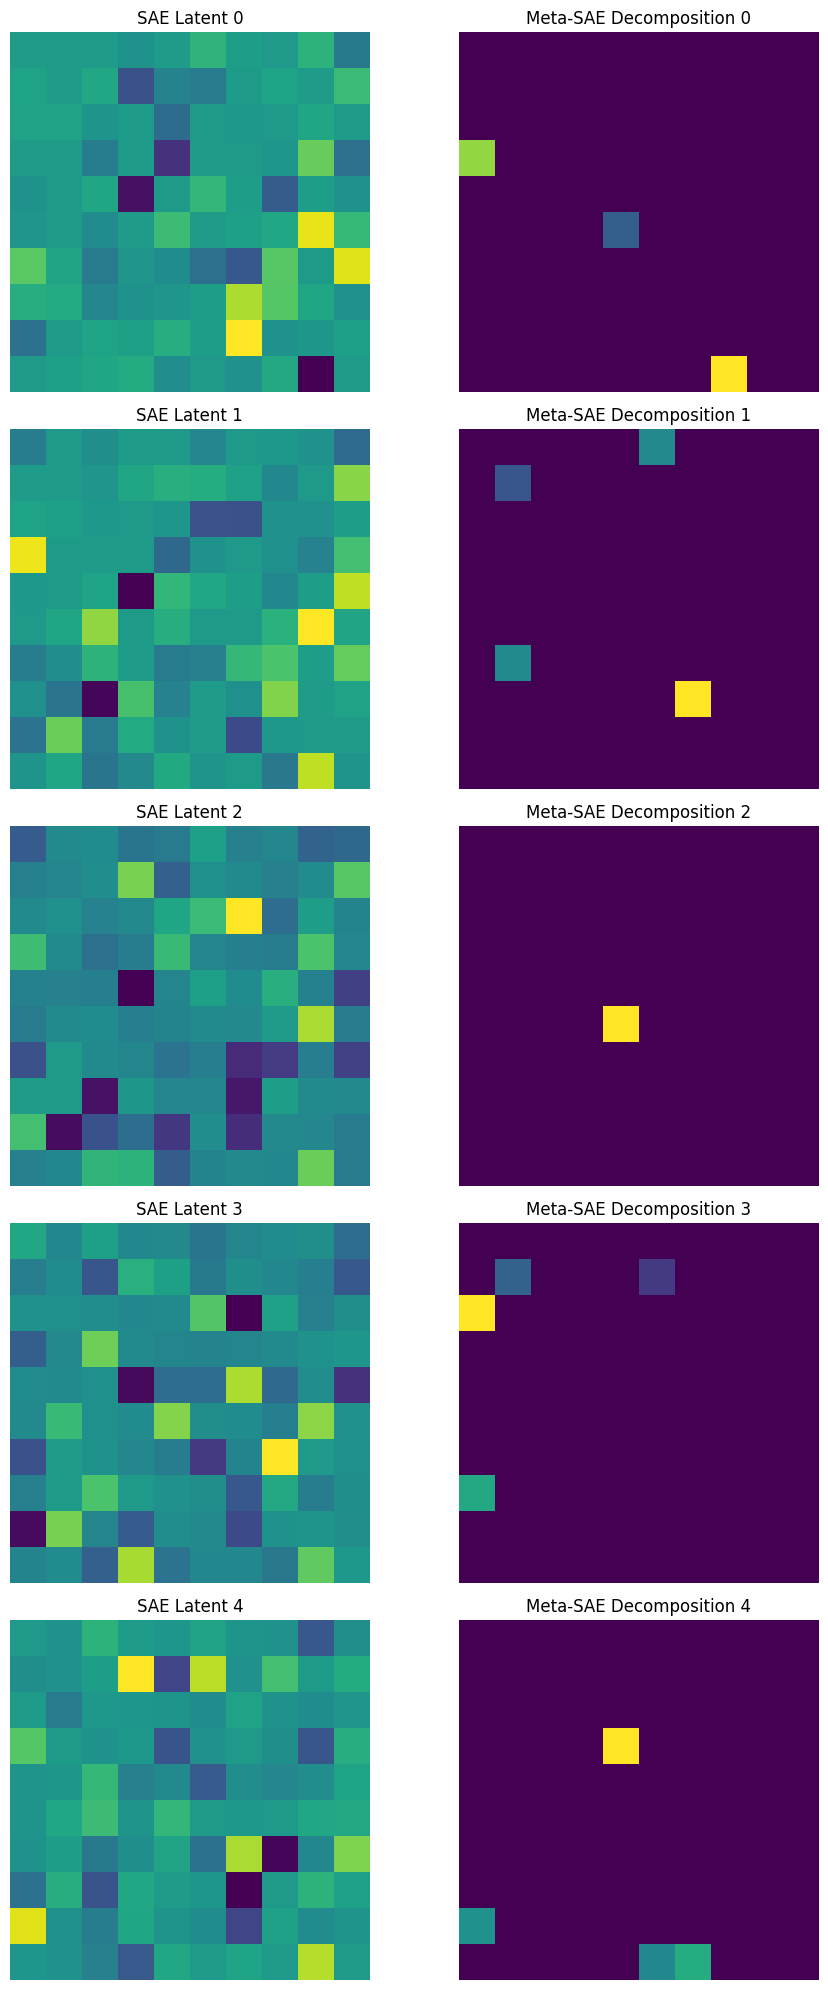

In [ ]:
# Fonction pour visualiser les meta-latents
def visualize_meta_latents(sae, meta_sae, num_latents=5):
    sae.eval()
    meta_sae.eval()

    with torch.no_grad():
        decoder_weights = sae.decoder.weight.t().detach()
        _, meta_encoded = meta_sae(decoder_weights)

    fig, axs = plt.subplots(num_latents, 2, figsize=(10, 4*num_latents))

    for i in range(num_latents):
        # SAE latent
        axs[i, 0].imshow(decoder_weights[:, i].cpu().numpy().reshape(int(np.sqrt(decoder_weights.shape[0])), -1), cmap='viridis')
        axs[i, 0].set_title(f"SAE Latent {i}")

        # Meta-SAE decomposition
        axs[i, 1].imshow(meta_encoded[i].cpu().numpy().reshape(int(np.sqrt(meta_encoded.shape[1])), -1), cmap='viridis')
        axs[i, 1].set_title(f"Meta-SAE Decomposition {i}")

    for ax in axs.flat:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Visualiser les meta-latents
visualize_meta_latents(sae, meta_sae)

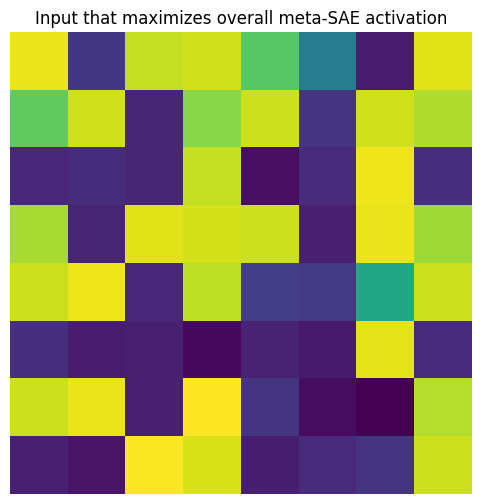

In [ ]:
def visualize_max_activation(meta_sae, num_iterations=100):
    meta_sae.eval()  # Assurez-vous que le meta-SAE est en mode évaluation

    # Créer une entrée aléatoire qui nécessite un gradient
    input = torch.randn(1, meta_sae.encoder.in_features, requires_grad=True, device=device)
    optimizer = optim.Adam([input], lr=0.1)

    for _ in range(num_iterations):
        optimizer.zero_grad()

        # Forward pass
        with torch.set_grad_enabled(True):
            _, encoded = meta_sae(input)
            loss = -encoded.abs().mean()  # Maximiser l'activation moyenne absolue

        # Backward pass
        loss.backward()
        optimizer.step()

    # Visualiser l'entrée optimisée
    plt.figure(figsize=(6, 6))
    plt.imshow(input.detach().cpu().numpy().reshape(int(np.sqrt(input.shape[1])), -1), cmap='viridis')
    plt.title("Input that maximizes overall meta-SAE activation")
    plt.axis('off')
    plt.show()

# Visualiser l'entrée qui maximise l'activation globale du meta-SAE
visualize_max_activation(meta_sae)

Using device: cuda
1. Original prediction
Original output shape: torch.Size([64, 10])
Original prediction: 7

2. Transformer activations
Transformer activations shape: torch.Size([64, 1, 64])

3. SAE encoding
SAE encoded shape: torch.Size([64, 64])

4. Meta-SAE encoding
Meta-SAE encoded shape: torch.Size([64, 100])

5. Intervention on meta-latent
Modified meta-encoded shape: torch.Size([64, 100])

6. Meta-SAE decoding
Reconstructed SAE shape: torch.Size([64, 64])

7. Adjusting reconstructed SAE shape
Adjusted reconstructed SAE shape: torch.Size([64, 100])

8. SAE decoding
Reconstructed activation shape: torch.Size([64, 64])

9. Reshaping for transformer
Reshaped activation shape: torch.Size([64, 1, 64])

10. Passing through transformer layers
Transformed activation shape: torch.Size([64, 1, 64])

11. Passing through final linear layer
Modified output shape: torch.Size([64, 10])
Modified prediction: 2


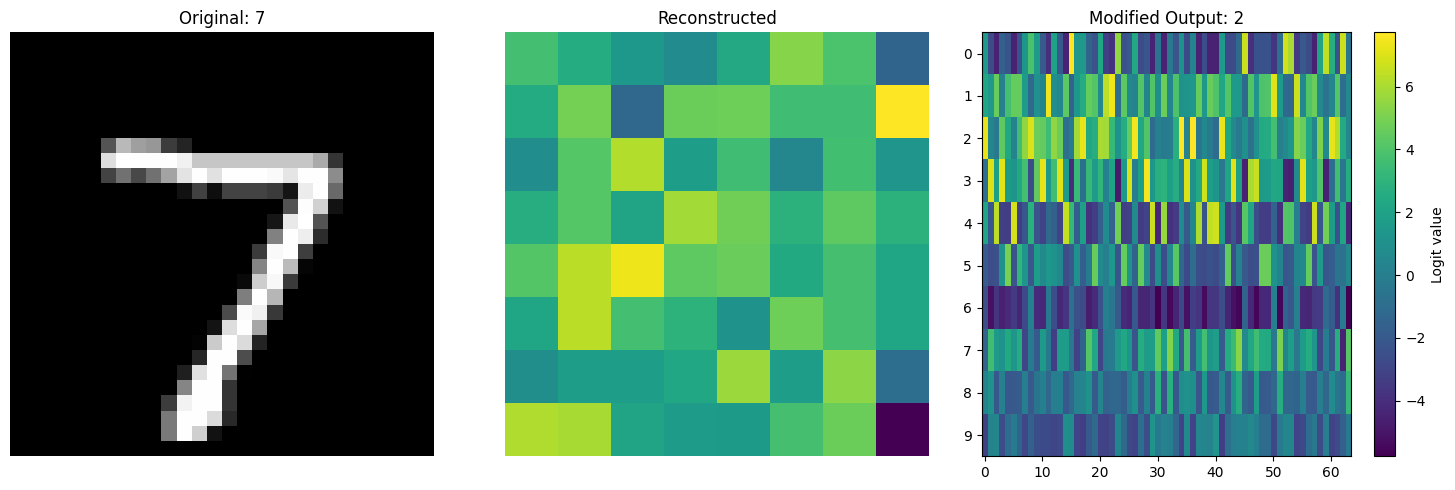

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def intervene_and_observe(meta_sae, sae, transformer, test_loader, latent_index, scale=5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    meta_sae.to(device)
    sae.to(device)
    transformer.to(device)

    meta_sae.eval()
    sae.eval()
    transformer.eval()

    for batch in test_loader:
        image, label = batch['pixel_values'].to(device), batch['label']

        with torch.no_grad():
            print("1. Original prediction")
            original_output = transformer(image)
            original_pred = torch.argmax(original_output, dim=1)
            print(f"Original output shape: {original_output.shape}")
            print(f"Original prediction: {original_pred[0].item()}")

            print("\n2. Transformer activations")
            _, activations = transformer(image, return_activations=True)
            print(f"Transformer activations shape: {activations.shape}")

            print("\n3. SAE encoding")
            sae_encoded, _ = sae(activations.squeeze(1))
            print(f"SAE encoded shape: {sae_encoded.shape}")

            print("\n4. Meta-SAE encoding")
            _, meta_encoded = meta_sae(sae_encoded)
            print(f"Meta-SAE encoded shape: {meta_encoded.shape}")

            print("\n5. Intervention on meta-latent")
            modified_meta_encoded = meta_encoded.clone()
            modified_meta_encoded[0, latent_index] += scale
            print(f"Modified meta-encoded shape: {modified_meta_encoded.shape}")

            print("\n6. Meta-SAE decoding")
            reconstructed_sae = meta_sae.decoder(modified_meta_encoded)
            print(f"Reconstructed SAE shape: {reconstructed_sae.shape}")

            print("\n7. Adjusting reconstructed SAE shape")
            adjusted_reconstructed_sae = F.pad(reconstructed_sae, (0, 36))  # Add 36 zeros to make it 100
            print(f"Adjusted reconstructed SAE shape: {adjusted_reconstructed_sae.shape}")

            print("\n8. SAE decoding")
            reconstructed_activation = sae.decoder(adjusted_reconstructed_sae)
            print(f"Reconstructed activation shape: {reconstructed_activation.shape}")

            print("\n9. Reshaping for transformer")
            reshaped_activation = reconstructed_activation.unsqueeze(1)  # Add sequence dimension
            print(f"Reshaped activation shape: {reshaped_activation.shape}")

            print("\n10. Passing through transformer layers")
            for layer in transformer.transformer_layers:
                reshaped_activation = layer(reshaped_activation)
            print(f"Transformed activation shape: {reshaped_activation.shape}")

            print("\n11. Passing through final linear layer")
            modified_output = transformer.fc(reshaped_activation.squeeze(1))
            print(f"Modified output shape: {modified_output.shape}")

            modified_pred = torch.argmax(modified_output, dim=1)
            print(f"Modified prediction: {modified_pred[0].item()}")

        # Visualisation
        plt.figure(figsize=(15, 5))

        # Image originale
        plt.subplot(1, 3, 1)
        plt.imshow(image[0].cpu().squeeze().numpy(), cmap='gray')
        plt.title(f"Original: {original_pred[0].item()}")
        plt.axis('off')

        # Image reconstruite
        plt.subplot(1, 3, 2)
        # Modification ici pour gérer la dimensionnalité
        reconstructed_image = reconstructed_activation[0].cpu().numpy()
        if reconstructed_image.shape[0] == 64:
            reconstructed_image = reconstructed_image.reshape(8, 8)
        elif reconstructed_image.shape[0] == 784:
            reconstructed_image = reconstructed_image.reshape(28, 28)
        else:
            print(f"Unexpected shape: {reconstructed_image.shape}")
            reconstructed_image = reconstructed_image.reshape(-1, int(reconstructed_image.shape[0]**0.5))
        plt.imshow(reconstructed_image, cmap='viridis')
        plt.title(f"Reconstructed")
        plt.axis('off')

        # Sortie modifiée
        plt.subplot(1, 3, 3)
        plt.imshow(modified_output.cpu().numpy().T, cmap='viridis', aspect='auto')
        plt.title(f"Modified Output: {modified_pred[0].item()}")
        plt.colorbar(label='Logit value')
        plt.yticks(range(10))

        plt.tight_layout()
        plt.show()

        break  # Juste un exemple

# Utilisation de la fonction
latent_index = 0  # Choisissez l'index du meta-latent à modifier
scale = 5  # Choisissez l'ampleur de la modification

intervene_and_observe(meta_sae, sae, transformer, test_loader, latent_index, scale)

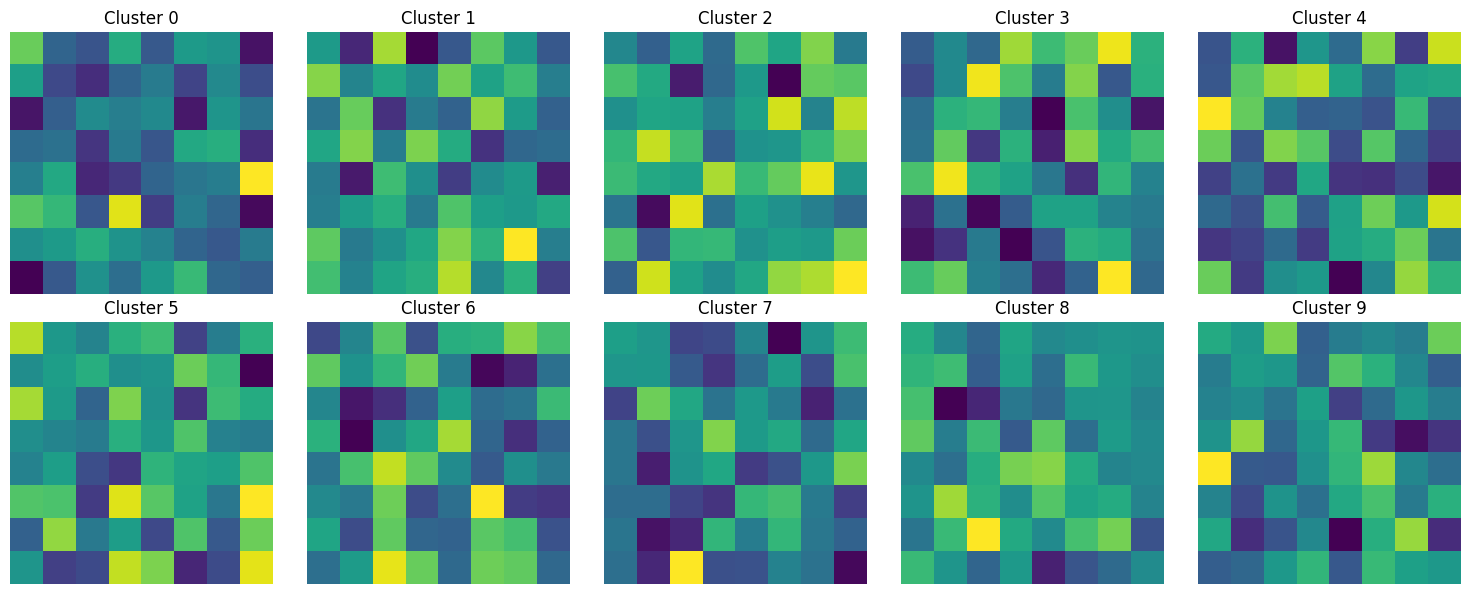

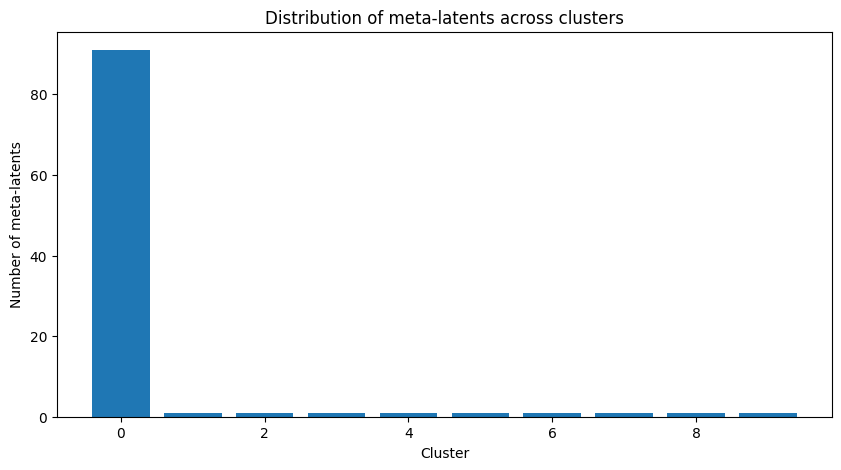

In [ ]:
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt

def cluster_meta_latents(meta_sae, n_clusters=10):
    meta_sae.eval()

    with torch.no_grad():
        # Obtenir les poids du décodeur du meta-SAE
        meta_latents = meta_sae.decoder.weight.t().cpu().numpy()

    # Appliquer K-means
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    clusters = kmeans.fit_predict(meta_latents)

    # Visualiser les centroïdes des clusters
    plt.figure(figsize=(15, 3 * ((n_clusters + 4) // 5)))
    for i in range(n_clusters):
        cluster_latents = meta_latents[clusters == i]
        centroid = cluster_latents.mean(axis=0)

        plt.subplot(((n_clusters + 4) // 5), 5, i+1)
        img_size = int(np.sqrt(centroid.shape[0]))
        plt.imshow(centroid.reshape(img_size, img_size), cmap='viridis')
        plt.title(f"Cluster {i}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

    # Afficher la distribution des clusters
    unique, counts = np.unique(clusters, return_counts=True)
    plt.figure(figsize=(10, 5))
    plt.bar(unique, counts)
    plt.xlabel("Cluster")
    plt.ylabel("Number of meta-latents")
    plt.title("Distribution of meta-latents across clusters")
    plt.show()

    return clusters

# Appeler la fonction
clusters = cluster_meta_latents(meta_sae)

# Questions qu'on se pose

## Deux modèles entraînés avec les mêmes paramètres ont-ils les mêmes *activations* ?

In [ ]:
# Initialisation des modèles
transformer1 = MNISTTransformer(d_model, nhead, num_layers)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(transformer1.parameters(), lr=learning_rate)

# Entraînement du Transformer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transformer1.to(device)

MNISTTransformer(
  (embedding): Linear(in_features=784, out_features=64, bias=True)
  (transformer_layers): ModuleList(
    (0-1): 2 x TransformerEncoderLayer(
      (self_attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
      )
      (linear1): Linear(in_features=64, out_features=2048, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (linear2): Linear(in_features=2048, out_features=64, bias=True)
      (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (dropout1): Dropout(p=0.1, inplace=False)
      (dropout2): Dropout(p=0.1, inplace=False)
    )
  )
  (fc): Linear(in_features=64, out_features=10, bias=True)
)

In [ ]:
for epoch in range(num_epochs):
    transformer1.train()
    total_loss = 0
    for batch in train_loader:
        inputs, labels = batch['pixel_values'].to(device), batch['label'].to(device)

        optimizer.zero_grad()
        outputs, _ = transformer1(inputs, return_activations=True)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)

    # Évaluation sur l'ensemble de test
    test_loss, test_accuracy = evaluate_transformer(transformer1, test_loader, criterion, device)

    print(f"Transformer1 Epoch [{epoch+1}/{num_epochs}]")
    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%")

print("Entraînement du Transformer1 terminé!")

Transformer1 Epoch [1/5]
  Train Loss: 0.3262
  Test Loss: 0.1777, Test Accuracy: 94.68%
Transformer1 Epoch [2/5]
  Train Loss: 0.1494
  Test Loss: 0.1367, Test Accuracy: 95.88%
Transformer1 Epoch [3/5]
  Train Loss: 0.1122
  Test Loss: 0.1273, Test Accuracy: 96.38%
Transformer1 Epoch [4/5]
  Train Loss: 0.0918
  Test Loss: 0.1059, Test Accuracy: 96.85%
Transformer1 Epoch [5/5]
  Train Loss: 0.0778
  Test Loss: 0.0863, Test Accuracy: 97.47%
Entraînement du Transformer1 terminé!


In [ ]:
# Initialisation des modèles
transformer2 = MNISTTransformer(d_model, nhead, num_layers)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(transformer2.parameters(), lr=learning_rate)

# Entraînement du Transformer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transformer2.to(device)

MNISTTransformer(
  (embedding): Linear(in_features=784, out_features=64, bias=True)
  (transformer_layers): ModuleList(
    (0-1): 2 x TransformerEncoderLayer(
      (self_attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
      )
      (linear1): Linear(in_features=64, out_features=2048, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (linear2): Linear(in_features=2048, out_features=64, bias=True)
      (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (dropout1): Dropout(p=0.1, inplace=False)
      (dropout2): Dropout(p=0.1, inplace=False)
    )
  )
  (fc): Linear(in_features=64, out_features=10, bias=True)
)

In [ ]:
for epoch in range(num_epochs):
    transformer2.train()
    total_loss = 0
    for batch in train_loader:
        inputs, labels = batch['pixel_values'].to(device), batch['label'].to(device)

        optimizer.zero_grad()
        outputs, _ = transformer2(inputs, return_activations=True)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)

    # Évaluation sur l'ensemble de test
    test_loss, test_accuracy = evaluate_transformer(transformer2, test_loader, criterion, device)

    print(f"Transformer2 Epoch [{epoch+1}/{num_epochs}]")
    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%")

print("Entraînement du Transformer2 terminé!")

Transformer2 Epoch [1/5]
  Train Loss: 0.3153
  Test Loss: 0.1776, Test Accuracy: 94.45%
Transformer2 Epoch [2/5]
  Train Loss: 0.1472
  Test Loss: 0.1358, Test Accuracy: 96.06%
Transformer2 Epoch [3/5]
  Train Loss: 0.1124
  Test Loss: 0.1173, Test Accuracy: 96.32%
Transformer2 Epoch [4/5]
  Train Loss: 0.0913
  Test Loss: 0.0972, Test Accuracy: 97.20%
Transformer2 Epoch [5/5]
  Train Loss: 0.0787
  Test Loss: 0.0977, Test Accuracy: 96.98%
Entraînement du Transformer2 terminé!


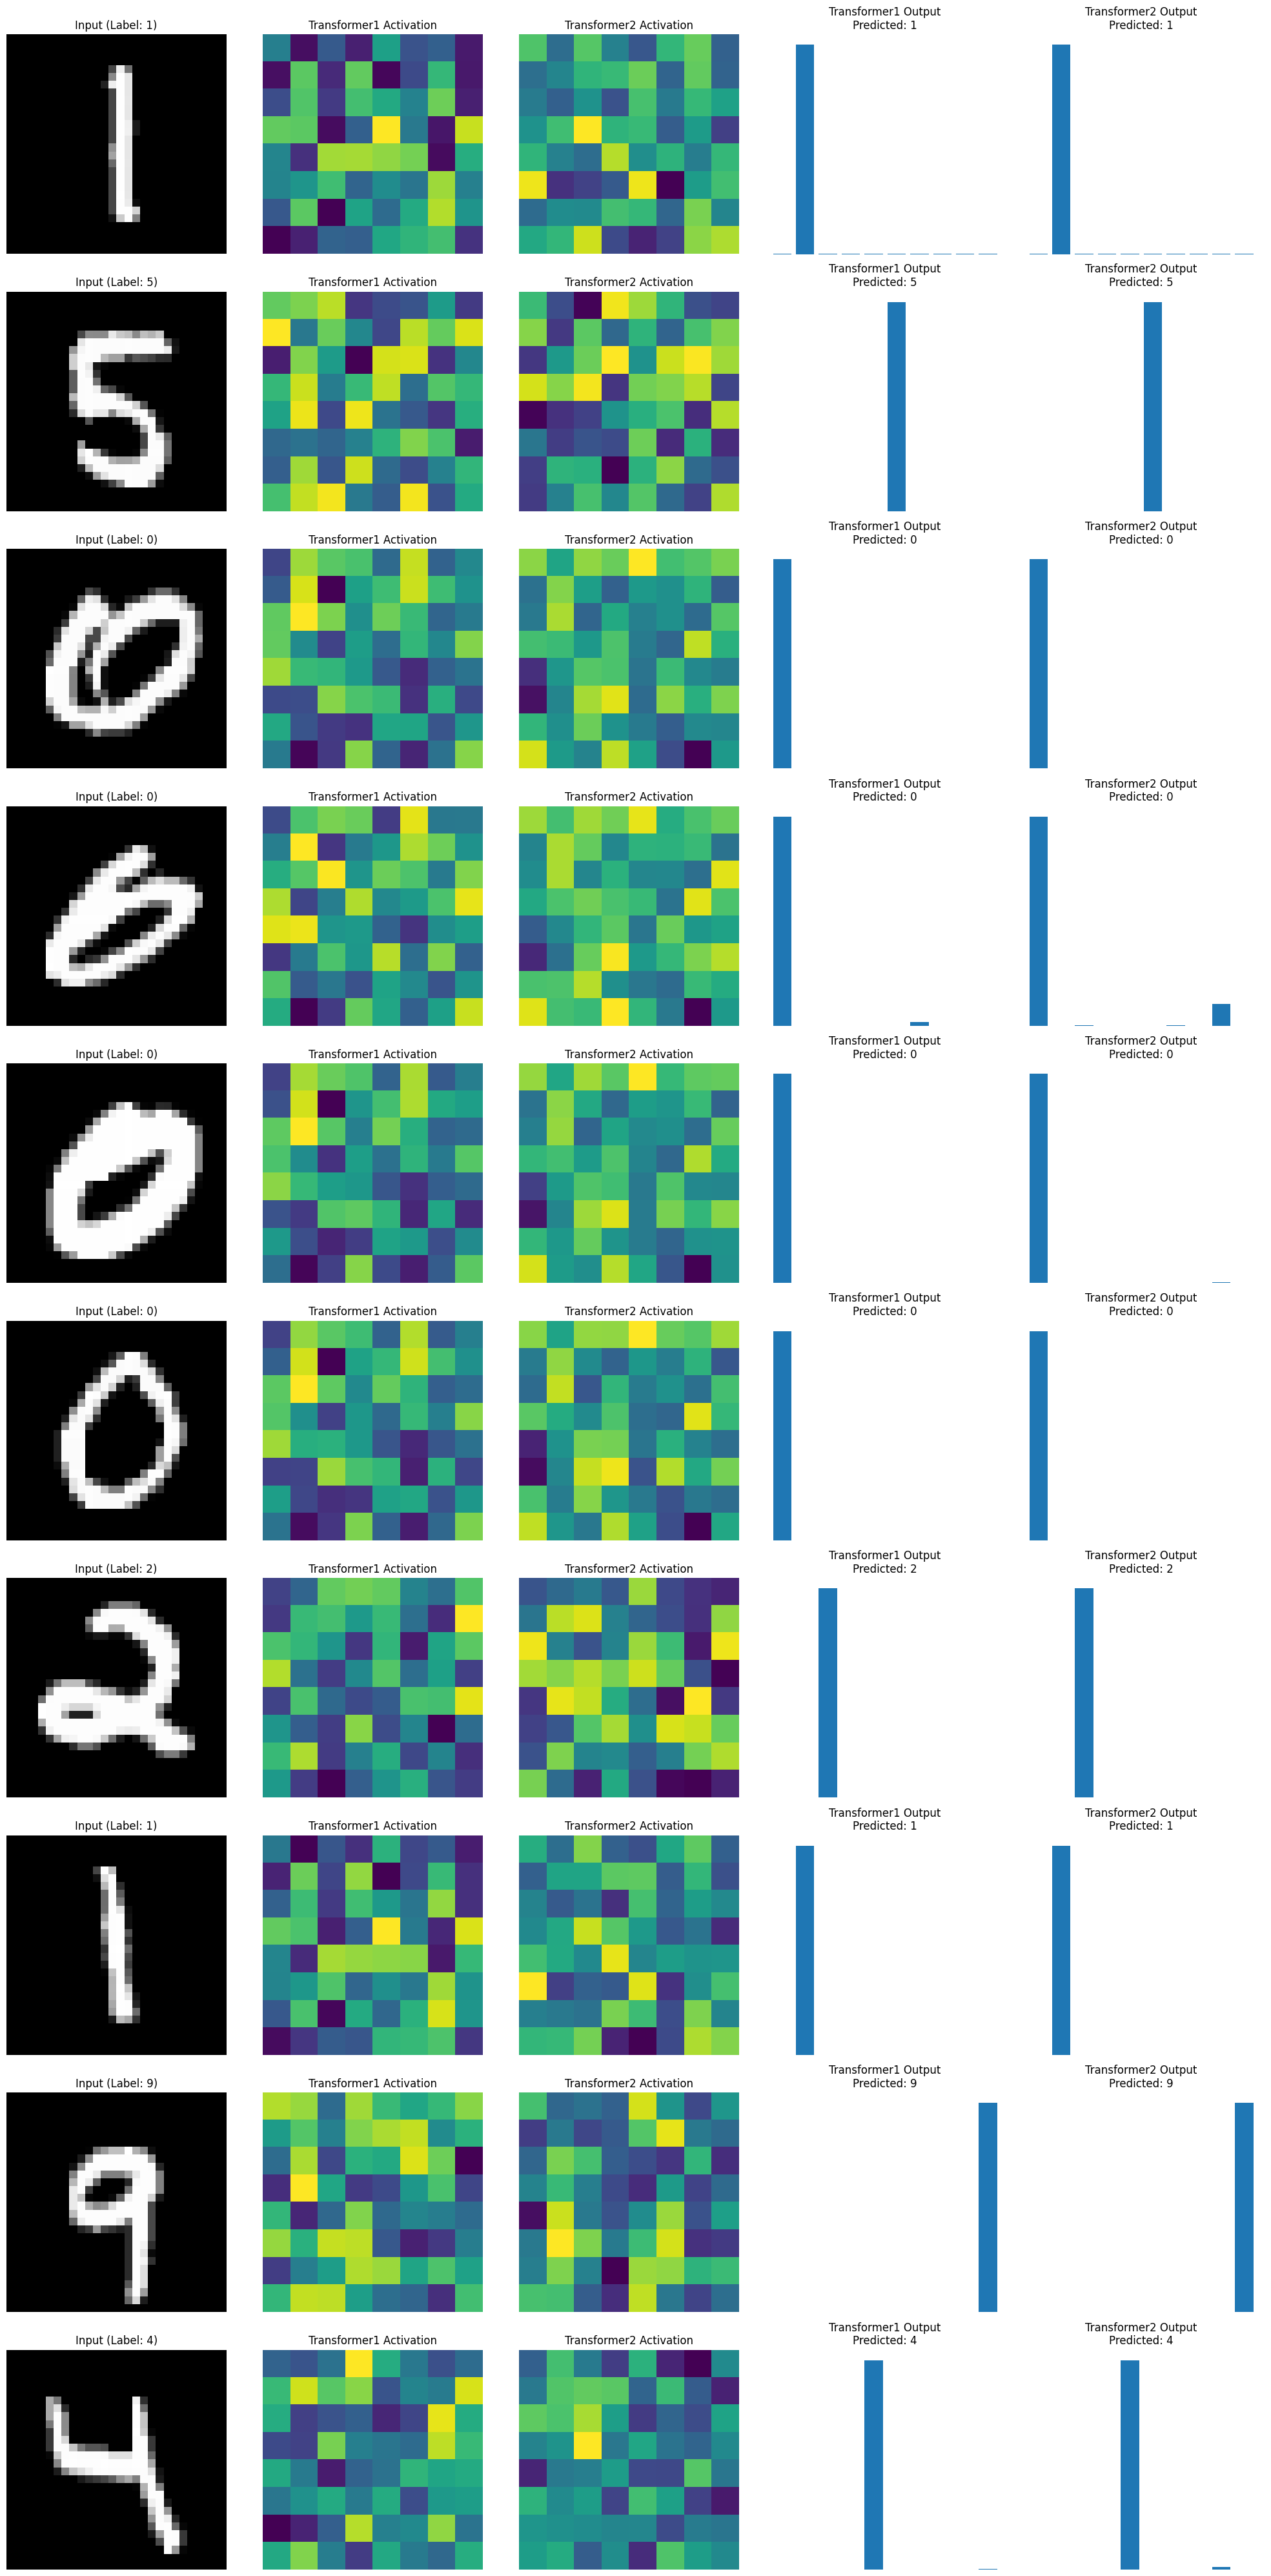

In [ ]:
def visualize_process(transformer1, transformer2, test_loader, num_samples=10):
    device = next(transformer1.parameters()).device
    transformer1.eval()
    transformer2.eval()

    # Sélectionner des échantillons aléatoires
    all_samples = []
    for batch in test_loader:
        all_samples.extend(list(zip(batch['pixel_values'], batch['label'])))
    random_samples = random.sample(all_samples, num_samples)

    fig, axs = plt.subplots(num_samples, 5, figsize=(20, 4*num_samples))

    for i, (image, label) in enumerate(random_samples):
        image = image.to(device)

        # Image originale
        axs[i, 0].imshow(image.cpu().squeeze().numpy(), cmap='gray')
        axs[i, 0].set_title(f"Input (Label: {label})")

        # Transformer1 activation
        with torch.no_grad():
            transformer1_output = transformer1(image.unsqueeze(0), return_activations=True)
            transformer1_activation = transformer1_output[-1].squeeze().cpu()

        # Transformer2 activation
        with torch.no_grad():
            transformer2_output = transformer2(image.unsqueeze(0), return_activations=True)
            transformer2_activation = transformer2_output[-1].squeeze().cpu()

        # Affichage de l'activation du Transformer1
        axs[i, 1].imshow(transformer1_activation.numpy().reshape(int(np.sqrt(transformer1_activation.shape[0])), -1), cmap='viridis')
        axs[i, 1].set_title("Transformer1 Activation")

        # Affichage de l'activation du Transformer2
        axs[i, 2].imshow(transformer2_activation.numpy().reshape(int(np.sqrt(transformer2_activation.shape[0])), -1), cmap='viridis')
        axs[i, 2].set_title("Transformer2 Activation")

        # Affichage de la sortie du Transformer1
        with torch.no_grad():
            transformer1_output = transformer1(image.unsqueeze(0))
            predicted_class1 = torch.argmax(transformer1_output).item()
        axs[i, 3].bar(range(10), nn.functional.softmax(transformer1_output.squeeze(), dim=0).cpu().numpy())
        axs[i, 3].set_title(f"Transformer1 Output\nPredicted: {predicted_class1}")
        axs[i, 3].set_xticks(range(10))

        # Affichage de la sortie du Transformer2
        with torch.no_grad():
            transformer2_output = transformer2(image.unsqueeze(0))
            predicted_class2 = torch.argmax(transformer2_output).item()
        axs[i, 4].bar(range(10), nn.functional.softmax(transformer2_output.squeeze(), dim=0).cpu().numpy())
        axs[i, 4].set_title(f"Transformer2 Output\nPredicted: {predicted_class2}")
        axs[i, 4].set_xticks(range(10))

    for ax in axs.flat:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Utilisation de la fonction
visualize_process(transformer1, transformer2, test_loader)

**La réponse à la question est donc NON, deux transformers de même architecture ne traitent pas les données de la même manière.**

Mais c'est un peu court ! On sent bien que d'une certaine manière, ces deux transformers réalisent la *même* fonction, mais l'implémentent d'une manière différente en quelque sorte.

En fait, nous allons voir que ce sont les *représentations* qui convergent vers la même chose, et non, dans l'absolu, les activations des neurones.

## Deux modèles entraînés avec les mêmes paramètres ont-ils les mêmes *représentations* ?

Reprenons nos deux modèle. Il existe de nombreuses métriques pour savoir si deux modèles partagent une même représentation. Une méthode simple pour cela est de calculer les plus proches voisins.

### Qu'est-ce que Cycle KNN ?

Cycle KNN (K-Nearest Neighbors) est une métrique utilisée pour comparer la similarité entre deux ensembles de représentations vectorielles, généralement issues de deux modèles différents ou de deux couches différentes d'un même modèle.

### Comment fonctionne Cycle KNN ?

Le processus se déroule en plusieurs étapes :

1. Pour chaque point dans l'ensemble A, on trouve ses K plus proches voisins dans l'ensemble B.
2. Pour chacun de ces K voisins dans B, on trouve leurs K plus proches voisins dans A.
3. On vérifie si le point original de A est parmi ces K voisins.

### Formulation mathématique

Soit $A = \{a_1, ..., a_n\}$ et $B = \{b_1, ..., b_n\}$ deux ensembles de vecteurs.

Définissons $NN_k(x, Y)$ comme l'ensemble des k plus proches voisins de x dans Y.

La précision Cycle KNN est alors définie comme :

$$\text{CycleKNN}(A, B, k) = \frac{1}{n} \sum_{i=1}^n \mathbb{1}[a_i \in NN_k(NN_k(a_i, B), A)]$$

où $\mathbb{1}[\cdot]$ est la fonction indicatrice.

### Interprétation

- Une valeur élevée (proche de 1) indique une forte correspondance entre les structures de voisinage dans A et B.
- Une valeur faible (proche de 0) suggère des structures de voisinage très différentes.

### Pourquoi est-ce utile dans ce contexte ?

1. **Comparaison de modèles** : Cycle KNN permet de comparer les représentations internes de différents modèles (ici, transformer1 et transformer2) sur les mêmes données d'entrée.

2. **Analyse de la préservation de structure** : Il aide à comprendre si les modèles préservent des structures similaires dans leurs espaces de représentation respectifs.

3. **Évaluation de la cohérence** : Une forte similarité Cycle KNN suggère que les deux modèles ont appris des représentations cohérentes, malgré d'éventuelles différences dans leurs architectures ou leurs processus d'entraînement.

4. **Détection de divergences** : Une faible similarité peut indiquer des divergences significatives dans la façon dont les modèles traitent et représentent les informations.

5. **Analyse de transfert d'apprentissage** : Dans le contexte du transfert d'apprentissage, Cycle KNN peut aider à évaluer à quel point les représentations apprises sont transférables entre les modèles.

En résumé, Cycle KNN fournit une mesure quantitative de la similarité structurelle entre les espaces de représentation de deux modèles, offrant ainsi des insights précieux sur leurs comportements internes et leurs capacités de généralisation.

In [ ]:
import torch
import torch.nn.functional as F
import random

def compute_nearest_neighbors(feats, topk=100):
    feats = F.normalize(feats, p=2, dim=1)
    sim_matrix = feats @ feats.T
    sim_matrix.fill_diagonal_(-float('inf'))
    return sim_matrix.argsort(dim=1, descending=True)[:, :topk]

def compute_knn_accuracy(knn):
    n = knn.shape[0]
    acc = knn == torch.arange(n, device=knn.device).view(-1, 1, 1)
    return acc.float().view(n, -1).max(dim=1).values.mean()

def cycle_knn(feats_A, feats_B, topk):
    print(f"Shape of feats_A: {feats_A.shape}, feats_B: {feats_B.shape}")
    print(f"Range of values in feats_A: [{feats_A.min():.4f}, {feats_A.max():.4f}]")
    print(f"Range of values in feats_B: [{feats_B.min():.4f}, {feats_B.max():.4f}]")

    knn_A = compute_nearest_neighbors(feats_A, topk)
    knn_B = compute_nearest_neighbors(feats_B, topk)

    print(f"Shape of knn_A: {knn_A.shape}, knn_B: {knn_B.shape}")

    accuracy = compute_knn_accuracy(knn_A[knn_B])
    print(f"Raw accuracy: {accuracy.item()}")

    return accuracy.item()

def collect_activations(model, data_loader, device, num_samples=500):
    model.eval()
    activations = []
    sample_count = 0
    with torch.no_grad():
        for batch in data_loader:
            inputs = batch['pixel_values'].to(device)
            _, batch_activations = model(inputs, return_activations=True)
            activations.append(batch_activations.squeeze(1).cpu())
            sample_count += batch_activations.shape[0]
            if sample_count >= num_samples:
                break
    activations = torch.cat(activations, dim=0)[:num_samples]
    return activations

# Utilisation
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Collecte des activations pour un sous-ensemble
activations1 = collect_activations(transformer1, train_loader, device, num_samples=500)
activations2 = collect_activations(transformer2, train_loader, device, num_samples=500)

print("Activations collected.")
print(f"activations1 shape: {activations1.shape}")
print(f"activations2 shape: {activations2.shape}")

# Calcul de la similarité
similarity = cycle_knn(activations1, activations2, topk=40)
print(f"La similarité cycle_knn entre transformer1 et transformer2 est : {similarity}")

Activations collected.
activations1 shape: torch.Size([500, 64])
activations2 shape: torch.Size([500, 64])
Shape of feats_A: torch.Size([500, 64]), feats_B: torch.Size([500, 64])
Range of values in feats_A: [-3.3848, 3.1561]
Range of values in feats_B: [-4.2418, 3.4259]
Shape of knn_A: torch.Size([500, 40]), knn_B: torch.Size([500, 40])
Raw accuracy: 0.9100000262260437
La similarité cycle_knn entre transformer1 et transformer2 est : 0.9100000262260437


In [ ]:
# Initialisation des modèles
transformer_alea = MNISTTransformer(d_model, nhead, num_layers)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(transformer_alea.parameters(), lr=learning_rate)

# Entraînement du Transformer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transformer_alea.to(device)

MNISTTransformer(
  (embedding): Linear(in_features=784, out_features=64, bias=True)
  (transformer_layers): ModuleList(
    (0-1): 2 x TransformerEncoderLayer(
      (self_attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
      )
      (linear1): Linear(in_features=64, out_features=2048, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (linear2): Linear(in_features=2048, out_features=64, bias=True)
      (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (dropout1): Dropout(p=0.1, inplace=False)
      (dropout2): Dropout(p=0.1, inplace=False)
    )
  )
  (fc): Linear(in_features=64, out_features=10, bias=True)
)

In [ ]:
# Collecte des activations pour un sous-ensemble
activations1 = collect_activations(transformer_alea, train_loader, device, num_samples=500)
activations2 = collect_activations(transformer2, train_loader, device, num_samples=500)

print("Activations collected.")
print(f"activations1 shape: {activations1.shape}")
print(f"activations2 shape: {activations2.shape}")

# Calcul de la similarité
similarity = cycle_knn(activations1, activations2, topk=40)
print(f"La similarité cycle_knn entre transformer1 et transformer2 est : {similarity}")

Activations collected.
activations1 shape: torch.Size([500, 64])
activations2 shape: torch.Size([500, 64])
Shape of feats_A: torch.Size([500, 64]), feats_B: torch.Size([500, 64])
Range of values in feats_A: [-3.4254, 2.5900]
Range of values in feats_B: [-3.9892, 3.2260]
Shape of knn_A: torch.Size([500, 40]), knn_B: torch.Size([500, 40])
Raw accuracy: 0.8519999980926514
La similarité cycle_knn entre transformer1 et transformer2 est : 0.8519999980926514
